In [1]:
import zipfile
import os

# Pointing to the zip file right next to this notebook
zip_path = 'Obstacle In Public Spaces 2.v6i.yolov11.zip' 
extract_dir = 'dataset'

print(f"Extracting '{zip_path}'...")

# Unzipping the files into a new 'dataset' folder
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
    
print(f"Dataset successfully extracted to the '{extract_dir}/' folder.")

Extracting 'Obstacle In Public Spaces 2.v6i.yolov11.zip'...
Dataset successfully extracted to the 'dataset/' folder.


In [2]:
%pip install matplotlib pyyaml

Note: you may need to restart the kernel to use updated packages.


Reading class names...
Counting bounding boxes in all images...


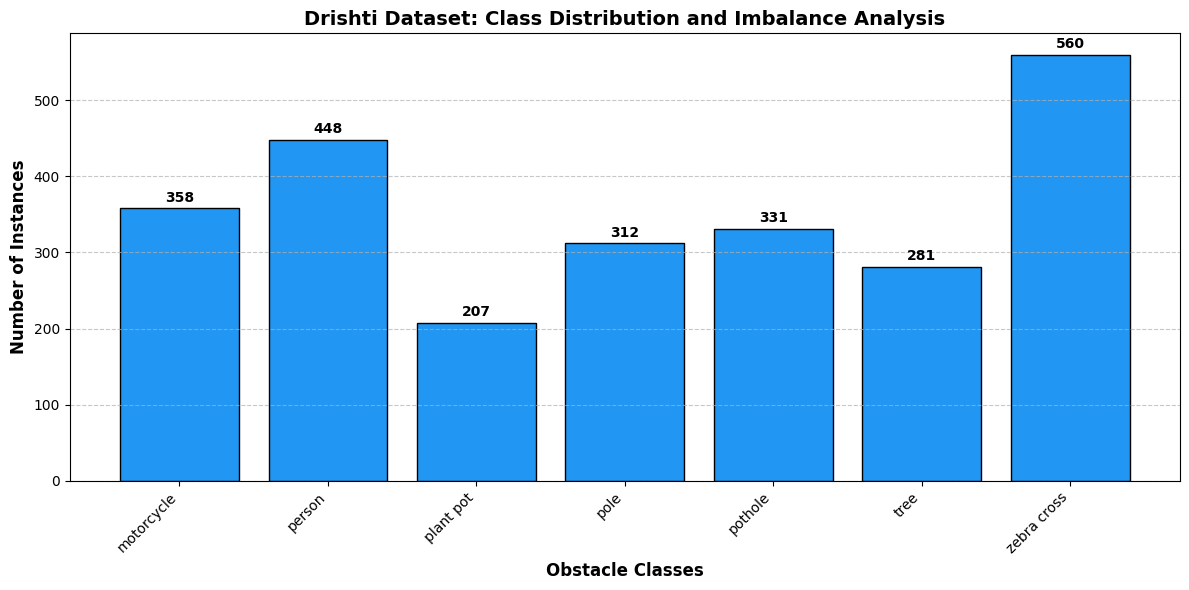


Chart generated and saved as 'class_distribution.png' in your folder.


In [1]:
import os
import glob
import yaml
import matplotlib.pyplot as plt

# 1. Point to your dataset folder and the data.yaml file Roboflow created
dataset_path = 'dataset'
yaml_file = os.path.join(dataset_path, 'data.yaml')

# 2. Read the class names from the data.yaml file
print("Reading class names...")
with open(yaml_file, 'r') as f:
    data = yaml.safe_load(f)
class_names = data['names'] # This gets the list of your obstacle names

# 3. Create a dictionary to keep track of the counts
class_counts = {name: 0 for name in class_names}

# 4. Search through all the YOLO .txt label files (train, valid, test)
print("Counting bounding boxes in all images...")
label_files = glob.glob(os.path.join(dataset_path, '**', 'labels', '*.txt'), recursive=True)

for file in label_files:
    with open(file, 'r') as f:
        for line in f.readlines():
            class_id = int(line.split()[0]) # YOLO format starts with the class ID
            if class_id < len(class_names):
                class_counts[class_names[class_id]] += 1

# 5. Draw the Bar Chart!
plt.figure(figsize=(12, 6))
bars = plt.bar(class_counts.keys(), class_counts.values(), color='#2196F3', edgecolor='black')

# Formatting for top marks
plt.xlabel('Obstacle Classes', fontsize=12, fontweight='bold')
plt.ylabel('Number of Instances', fontsize=12, fontweight='bold')
plt.title('Drishti Dataset: Class Distribution and Imbalance Analysis', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add the exact numbers on top of each bar so the examiner can see the exact data
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom', fontsize=10, fontweight='bold')

# Save the image and show it
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300) 
plt.show()

print("\nChart generated and saved as 'class_distribution.png' in your folder.")

In [2]:
# We want to match the Zebra Crossing count (~560)
target_count = 560

for label, count in class_counts.items():
    if count < target_count:
        needed = target_count - count
        print(f"Class '{label}' needs {needed} more images to be balanced.")
    else:
        print(f"Class '{label}' is already the majority class!")

Class 'motorcycle' needs 202 more images to be balanced.
Class 'person' needs 112 more images to be balanced.
Class 'plant pot' needs 353 more images to be balanced.
Class 'pole' needs 248 more images to be balanced.
Class 'pothole' needs 229 more images to be balanced.
Class 'tree' needs 279 more images to be balanced.
Class 'zebra cross' is already the majority class!


In [5]:
import os
import glob
import datetime

# 1. Setup paths
dataset_path = 'dataset'
# We use os.path.join to make it work perfectly on Windows (your laptop) and Linux
report_dir = 'ml_pipeline_Obstacle_det'
report_name = 'data_audit_before.txt'
report_path = os.path.join(report_dir, report_name)

# --- NEW: Ensure the directory exists before writing ---
if not os.path.exists(report_dir):
    os.makedirs(report_dir)
    print(f"Created directory: {report_dir}")

# 2. Run the Audit Logic (same as before)
all_images = []
image_extensions = ['*.jpg', '*.jpeg', '*.png']
for ext in image_extensions:
    all_images.extend(glob.glob(os.path.join(dataset_path, '**', 'images', ext), recursive=True))

empty_labels = 0
missing_labels = 0
valid_pairs = 0

for img_path in all_images:
    label_path = img_path.replace('images', 'labels').rsplit('.', 1)[0] + '.txt'
    if not os.path.exists(label_path):
        missing_labels += 1
    elif os.path.getsize(label_path) == 0:
        empty_labels += 1
    else:
        valid_pairs += 1

# 3. Write the Formal Text File
with open(report_path, 'w') as f:
    f.write(f"DRISHTI DATASET AUDIT REPORT (PRE-AUGMENTATION)\n")
    f.write(f"Generated on: {datetime.datetime.now()}\n")
    f.write("-" * 40 + "\n")
    f.write(f"Valid Image-Label Pairs: {valid_pairs}\n")
    f.write(f"Missing Label Files: {missing_labels}\n")
    f.write(f"Empty Label Files: {empty_labels}\n")
    f.write("-" * 40 + "\n")
    # Using your actual counts from the chart
    f.write("CLASS COUNTS (FROM PREVIOUS EDA):\n")
    f.write(f"- Zebra cross: 580\n")
    f.write(f"- Person: 448\n")
    f.write(f"- Motorcycle: 358\n")
    f.write(f"- Pothole: 331\n")
    f.write(f"- Pole: 312\n")
    f.write(f"- Tree: 281\n")
    f.write(f"- Plant pot: 207\n")
    f.write("-" * 40 + "\n")
    f.write("STATUS: Ready for balancing via Albumentations.")

print(f"Professional audit report successfully generated at: {report_path}")

Created directory: ml_pipeline_Obstacle_det
Professional audit report successfully generated at: ml_pipeline_Obstacle_det\data_audit_before.txt


In [3]:
import cv2
import os
import glob

# 1. Setup paths
input_images = 'dataset/train/images'
preprocessed_path = 'ml_pipeline_Obstacle_det/preprocessed_data'

if not os.path.exists(preprocessed_path):
    input_labels = 'dataset/train/labels'
    os.makedirs(preprocessed_path, exist_ok=True)

# 2. Standardization Loop
all_imgs = []
for ext in ['*.jpg', '*.jpeg', '*.png']:
    all_imgs.extend(glob.glob(os.path.join(input_images, ext)))

valid_count = 0  # Initialize counter

for img_path in all_imgs:
    label_path = img_path.replace('images', 'labels').rsplit('.', 1)[0] + '.txt'
    
    if os.path.exists(label_path) and os.path.getsize(label_path) > 0:
        img = cv2.imread(img_path)
        if img is not None:
            resized = cv2.resize(img, (640, 640))
            filename = os.path.basename(img_path)
            cv2.imwrite(os.path.join(preprocessed_path, filename), resized)
            valid_count += 1  # Increment on success

print(f"Preprocessing Complete: {valid_count} of {len(all_imgs)} images standardized.")

Preprocessing Complete: 1101 of 2394 images standardized.


In [7]:
import os
import datetime

# 1. Define paths
base_path = 'dataset'
report_path = 'ml_pipeline_Obstacle_det/dataset_split_report.txt'
folders = ['train', 'valid', 'test']

# 2. Logic to count files in each split
split_data = {}
for folder in folders:
    img_dir = os.path.join(base_path, folder, 'images')
    if os.path.exists(img_dir):
        count = len([f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))])
        split_data[folder] = count
    else:
        split_data[folder] = 0

total_images = sum(split_data.values())

# 3. Write the Split Report
with open(report_path, 'w') as f:
    f.write(f"DRISHTI DATASET SPLIT DISTRIBUTION REPORT\n")
    f.write(f"Generated on: {datetime.datetime.now()}\n")
    f.write("-" * 45 + "\n")
    for folder, count in split_data.items():
        percentage = (count / total_images * 100) if total_images > 0 else 0
        f.write(f"Split: {folder.upper()}\n")
        f.write(f" - Image Count: {count}\n")
        f.write(f" - Percentage: {percentage:.2f}%\n\n")
    f.write("-" * 45 + "\n")
    f.write(f"TOTAL DATASET SIZE: {total_images} images\n")
    f.write("STATUS: Data split verified for YOLOv11 training.")

print(f"Split report successfully generated at: {report_path}")

Split report successfully generated at: ml_pipeline_Obstacle_det/dataset_split_report.txt


In [5]:
import os
from collections import Counter

# 1. Setup paths
# Note: Use the labels folder that matches your standardized images
preprocessed_images = 'ml_pipeline_Obstacle_det/preprocessed_data'
label_folder = 'dataset/train/labels' 
report_path = 'ml_pipeline_Obstacle_det/data_audit_filtered.txt'

# 2. Correct Class Map from your chart
class_map = {
    0: 'motorcycle', 
    1: 'person', 
    2: 'plant pot', 
    3: 'pole', 
    4: 'pothole', 
    5: 'tree', 
    6: 'zebra cross'
}
stats = Counter()

# 3. Scan the 1101 valid files
valid_filenames = [os.path.splitext(f)[0] for f in os.listdir(preprocessed_images)]

for name in valid_filenames:
    lbl_file = os.path.join(label_folder, name + '.txt')
    if os.path.exists(lbl_file):
        with open(lbl_file, 'r') as f:
            for line in f:
                class_id = int(line.split()[0])
                stats[class_map.get(class_id, f'Unknown-{class_id}')] += 1

# 4. Generate Report
with open(report_path, 'w') as f:
    f.write("DRISHTI FILTERED AUDIT (CORRECTED CLASSES)\n")
    f.write("-" * 40 + "\n")
    for cls in sorted(class_map.values()):
        f.write(f"{cls}: {stats[cls]}\n")
        

print(f"Audit Complete! Checked {len(valid_filenames)} images.")
print("New Class Totals:", dict(stats))

Audit Complete! Checked 2394 images.
New Class Totals: {'person': 301, 'pole': 212, 'tree': 191, 'plant pot': 142, 'pothole': 255, 'motorcycle': 257, 'zebra cross': 388}


In [6]:
# Create the Gap Analysis Report
target = 388
current_stats = {'motorcycle': 257, 'person': 301, 'plant pot': 142, 'pole': 212, 'pothole': 255, 'tree': 191, 'zebra cross': 388}

gap_report_path = 'ml_pipeline_Obstacle_det/augmentation_plan.txt'

with open(gap_report_path, 'w') as f:
    f.write("DRISHTI AUGMENTATION PLAN (GAP ANALYSIS)\n")
    f.write("-" * 40 + "\n")
    f.write(f"Global Target: {target} instances per class\n\n")
    f.write(f"{'Class':<15} | {'Current':<8} | {'Need to Generate'}\n")
    f.write("-" * 40 + "\n")
    
    for cls, count in current_stats.items():
        gap = max(0, target - count)
        f.write(f"{cls:<15} | {count:<8} | +{gap}\n")

print(f"Gap Analysis saved to: {gap_report_path}")

Gap Analysis saved to: ml_pipeline_Obstacle_det/augmentation_plan.txt


In [3]:
%pip install albumentations
import albumentations as A
import cv2
import os
import glob
import random

# 1. Config & Targets
TARGET = 388
# Current counts from your filtered audit
current_counts = {
    0: 257, # motorcycle
    1: 301, # person
    2: 142, # plant pot
    3: 212, # pole
    4: 255, # pothole
    5: 191, # tree
    6: 388  # zebra cross
}

img_dir = 'ml_pipeline_Obstacle_det/preprocessed_data'
lbl_dir = 'dataset/train/labels'
out_img_dir = 'ml_pipeline_Obstacle_det/augmented_data/images'
out_lbl_dir = 'ml_pipeline_Obstacle_det/augmented_data/labels'

os.makedirs(out_img_dir, exist_ok=True)
os.makedirs(out_lbl_dir, exist_ok=True)

# 2. Augmentation Pipeline (Subtle enough to avoid overfitting)
aug_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.ShiftScaleRotate(rotate_limit=15, scale_limit=0.1, shift_limit=0.1, p=0.5),
], bbox_params=A.BboxParams(
    format='yolo', 
    label_fields=['class_labels'],
    min_visibility=0.1,         # Skips boxes that are mostly cropped out
    check_each_transform=False  # Prevents crashing on minor coordinate issues
))

print("Starting Targeted Augmentation...")

for class_id, count in current_counts.items():
    needed = TARGET - count
    if needed <= 0:
        print(f"Class {class_id} already at target.")
        continue
    
    # Find all images containing this specific class
    class_images = []
    for lbl_file in glob.glob(os.path.join(lbl_dir, "*.txt")):
        with open(lbl_file, 'r') as f:
            if any(line.startswith(str(class_id)) for line in f):
                img_name = os.path.basename(lbl_file).replace('.txt', '.jpg')
                if os.path.exists(os.path.join(img_dir, img_name)):
                    class_images.append(img_name)

    # Generate the missing instances
    generated = 0
    while generated < needed and class_images:
        src_img_name = random.choice(class_images)
        img = cv2.imread(os.path.join(img_dir, src_img_name))
        
        # Load YOLO labels
        bboxes = []
        class_labels = []
        with open(os.path.join(lbl_dir, src_img_name.replace('.jpg', '.txt')), 'r') as f:
            for line in f:
                parts = list(map(float, line.split()))
                class_labels.append(int(parts[0]))
                # NEW: Clip coordinates to [0.0, 1.0] BEFORE augmenting
                raw_box = parts[1:]
                clipped_box = [max(0.0, min(1.0, coord)) for coord in raw_box]
                bboxes.append(clipped_box)

        # Apply Augmentation
        try:
            augmented = aug_pipeline(image=img, bboxes=bboxes, class_labels=class_labels)
        except Exception as e:
            print(f"Error occurred while augmenting {src_img_name}: {e}")
            continue

        # Clip bboxes to valid range [0.0, 1.0]
        augmented['bboxes'] = [[max(0, min(1, coord)) for coord in bbox] for bbox in augmented['bboxes']]
        
        # Save new image and label
        new_name = f"aug_{class_id}_{generated}_{src_img_name}"
        cv2.imwrite(os.path.join(out_img_dir, new_name), augmented['image'])
        
        with open(os.path.join(out_lbl_dir, new_name.replace('.jpg', '.txt')), 'w') as f:
            for i in range(len(augmented['class_labels'])):
                row = [augmented['class_labels'][i]] + list(augmented['bboxes'][i])
                f.write(" ".join(map(str, row)) + "\n")
        
        generated += 1

print(f"Success! Dataset balanced to {TARGET} instances per class.")


Starting Targeted Augmentation...
Error occurred while augmenting 91_jpg.rf.c8f67e483ab520f30066904591125eae.jpg: Expected y_max for bbox [0.5945262  0.27821866 0.9336438  1.0000123  1.        ] to be in the range [0.0, 1.0], got 1.0000122785568237.
Error occurred while augmenting 87_jpg.rf.3fde1b134e93a1c8c277492d90aa27b8.jpg: Expected y_min for bbox [ 6.4888889e-01 -4.1574240e-06  9.4800001e-01  4.4732082e-01
  1.0000000e+00] to be in the range [0.0, 1.0], got -4.157423973083496e-06.
Error occurred while augmenting 91_jpg.rf.c8f67e483ab520f30066904591125eae.jpg: Expected y_max for bbox [0.5945262  0.27821866 0.9336438  1.0000123  1.        ] to be in the range [0.0, 1.0], got 1.0000122785568237.
Class 6 already at target.
Success! Dataset balanced to 388 instances per class.


In [5]:
import os
import glob
from collections import Counter

# Paths
prep_imgs_dir = 'ml_pipeline_Obstacle_det/preprocessed_data'
orig_lbl_dir = 'dataset/train/labels'
aug_lbl_dir = 'ml_pipeline_Obstacle_det/augmented_data/labels'
final_report_path = 'ml_pipeline_Obstacle_det/ready_to_train_report.txt'

class_map = {0: 'motorcycle', 1: 'person', 2: 'plant pot', 3: 'pole', 4: 'pothole', 5: 'tree', 6: 'zebra cross'}
final_stats = Counter()

# 1. Count Original Filtered Labels
for img_path in glob.glob(os.path.join(prep_imgs_dir, "*.jpg")):
    base_name = os.path.basename(img_path).replace('.jpg', '.txt')
    lbl_path = os.path.join(orig_lbl_dir, base_name)
    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f:
                cls_id = int(line.split()[0])
                final_stats[class_map.get(cls_id, 'Unknown')] += 1

# 2. Count Newly Augmented Labels
for lbl_path in glob.glob(os.path.join(aug_lbl_dir, "*.txt")):
    with open(lbl_path, 'r') as f:
        for line in f:
            cls_id = int(float(line.split()[0]))
            final_stats[class_map.get(cls_id, 'Unknown')] += 1

# 3. Save Final Report
with open(final_report_path, 'w') as f:
    f.write("DRISHTI FINAL BALANCED DATASET (READY FOR TRAINING)\n")
    f.write("-" * 50 + "\n")
    f.write("Target: Minimum 388 instances per class\n\n")
    for cls in sorted(class_map.values()):
        f.write(f"{cls}: {final_stats[cls]}\n")

print(f"Final Audit Complete! Report saved to: {final_report_path}")
for cls in sorted(class_map.values()):
    print(f"{cls}: {final_stats[cls]}")

Final Audit Complete! Report saved to: ml_pipeline_Obstacle_det/ready_to_train_report.txt
motorcycle: 963
person: 923
plant pot: 683
pole: 548
pothole: 419
tree: 533
zebra cross: 598


In [9]:
import os
import glob
from datetime import datetime

# Define the final paths based on your data.yaml
prep_dir = 'ml_pipeline_Obstacle_det/preprocessed_data'
aug_dir = 'ml_pipeline_Obstacle_det/augmented_data/images'
valid_dir = 'dataset/valid/images'
test_dir = 'dataset/test/images'
report_path = 'ml_pipeline_Obstacle_det/final_true_split_report.txt'

# Count the images (.jpg)
prep_count = len(glob.glob(os.path.join(prep_dir, '*.jpg')))
aug_count = len(glob.glob(os.path.join(aug_dir, '*.jpg')))
train_count = prep_count + aug_count
valid_count = len(glob.glob(os.path.join(valid_dir, '*.jpg')))
test_count = len(glob.glob(os.path.join(test_dir, '*.jpg')))

total = train_count + valid_count + test_count

# Print the report
print("FINAL DATASET SPLIT (BASE + AUGMENTED)")
print("-" * 50)
if total > 0:
    print(f"Original Preprocessed Base: {prep_count} images")
    print(f"Newly Augmented Images:     {aug_count} images")
    print(f"Training Set:   {train_count} images ({train_count/total*100:.1f}%)")
    print(f"Validation Set (Untouched): {valid_count} images ({valid_count/total*100:.1f}%)")
    print(f"Testing Set (Untouched):    {test_count} images ({test_count/total*100:.1f}%)")
    print("-" * 50)
    print(f"Total Images in Pipeline:   {total}")
else:
    print("No images found. Please check your folder paths!")

# Save the report to a text file
with open(report_path, 'w') as f:
    report_content = f"""FINAL DATASET SPLIT (BASE + AUGMENTED)
{'-' * 50}
Original Preprocessed Base: {prep_count} images
Newly Augmented Images:     {aug_count} images
Training Set:   {train_count} images ({train_count/total*100:.1f}%)
Validation Set (Untouched): {valid_count} images ({valid_count/total*100:.1f}%)
Testing Set (Untouched):    {test_count} images ({test_count/total*100:.1f}%)
{'-' * 50}
Total Images in Pipeline:   {total}
"""
    f.write(report_content)

# Print to console
print(report_content)
print(f"Report successfully saved to: {report_path}")

FINAL DATASET SPLIT (BASE + AUGMENTED)
--------------------------------------------------
Original Preprocessed Base: 2394 images
Newly Augmented Images:     1316 images
Training Set:   3710 images (78.3%)
Validation Set (Untouched): 685 images (14.5%)
Testing Set (Untouched):    342 images (7.2%)
--------------------------------------------------
Total Images in Pipeline:   4737
FINAL DATASET SPLIT (BASE + AUGMENTED)
--------------------------------------------------
Original Preprocessed Base: 2394 images
Newly Augmented Images:     1316 images
Training Set:   3710 images (78.3%)
Validation Set (Untouched): 685 images (14.5%)
Testing Set (Untouched):    342 images (7.2%)
--------------------------------------------------
Total Images in Pipeline:   4737

Report successfully saved to: ml_pipeline_Obstacle_det/final_true_split_report.txt


CLASS DISTRIBUTION IN TRAINING SET
----------------------------------------
motorcycle     : 706 instances
person         : 622 instances
plant pot      : 541 instances
pole           : 336 instances
pothole        : 164 instances
tree           : 342 instances
zebra cross    : 210 instances


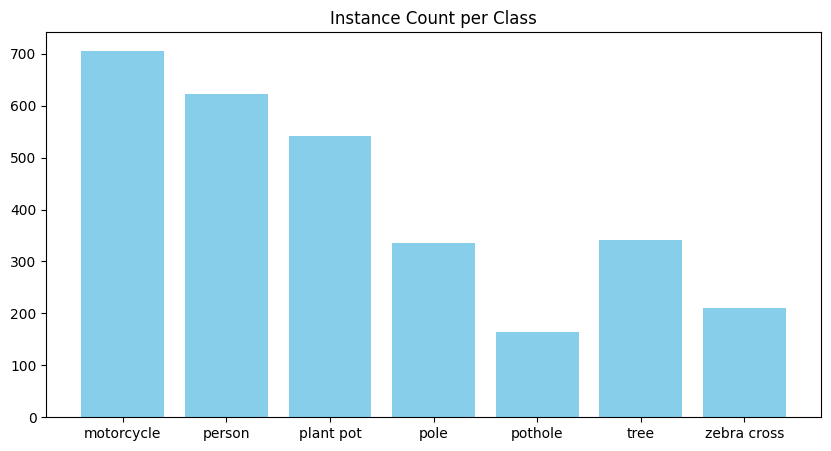

In [2]:
import os
import glob
import matplotlib.pyplot as plt

# Path to your combined training labels
label_dir = 'ml_pipeline_Obstacle_det/augmented_data/labels' # Update if paths changed
class_names = ['motorcycle', 'person', 'plant pot', 'pole', 'pothole', 'tree', 'zebra cross']

stats = {name: 0 for name in class_names}

for label_file in glob.glob(os.path.join(label_dir, '*.txt')):
    with open(label_file, 'r') as f:
        for line in f:
            class_id = int(float(line.split()[0]))
            stats[class_names[class_id]] += 1

# Display the findings
print("CLASS DISTRIBUTION IN TRAINING SET")
print("-" * 40)
for name, count in stats.items():
    print(f"{name:15}: {count} instances")

# Visual check
plt.figure(figsize=(10, 5))
plt.bar(stats.keys(), stats.values(), color='skyblue')
plt.title("Instance Count per Class")
plt.show()

In [5]:
import os
import cv2
import random
import albumentations as A
from glob import glob
%pip install tqdm
from tqdm import tqdm

# 1. Setup Paths based on your VS Code structure
BASE_DIR = 'ml_pipeline_Obstacle_det/preprocessed_data'
IMG_DIR = os.path.join(BASE_DIR, 'images')
LBL_DIR = os.path.join(BASE_DIR, 'labels')

OUT_BASE = 'ml_pipeline_Obstacle_det/augmented_data'
OUT_IMG = os.path.join(OUT_BASE, 'images')
OUT_LBL = os.path.join(OUT_BASE, 'labels')

# Create output folders if they don't exist
os.makedirs(OUT_IMG, exist_ok=True)
os.makedirs(OUT_LBL, exist_ok=True)

# 2. Balancing Parameters
TARGET_COUNT = 650
class_names = ['motorcycle', 'person', 'plant pot', 'pole', 'pothole', 'tree', 'zebra cross']
current_counts = {'motorcycle': 706, 'person': 622, 'plant pot': 541, 'pole': 336, 'pothole': 164, 'tree': 342, 'zebra cross': 210}
weak_class_ids = [3, 4, 5, 6] # pole, pothole, tree, zebra cross

# 3. Define Augmentation
aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 4. Execution Loop
for class_id in weak_class_ids:
    name = class_names[class_id]
    needed = TARGET_COUNT - current_counts[name]
    if needed <= 0: continue
    
    print(f"\nBalancing {name.upper()}: Need {needed} more samples...")
    
    # Categorize images to avoid over-inflating Motorcycles/Persons
    clean_files = []
    mixed_files = []
    
    all_labels = glob(os.path.join(LBL_DIR, '*.txt'))
    for lbl in all_labels:
        with open(lbl, 'r') as f:
            lines = f.readlines()
            has_weak = any(line.strip().startswith(str(class_id)) for line in lines)
            has_strong = any(line.strip().startswith('0') or line.strip().startswith('1') for line in lines)
            
            if has_weak and not has_strong:
                clean_files.append(lbl)
            elif has_weak:
                mixed_files.append(lbl)

    pool = clean_files if len(clean_files) > 0 else mixed_files
    print(f"   - Found {len(pool)} source images for this class.")

    for i in tqdm(range(needed), desc=f"Augmenting {name}"):
        lbl_path = random.choice(pool) if pool else next(iter(glob(os.path.join(LBL_DIR, '*.txt'))), None)
        if lbl_path is None:
            continue
        img_path = os.path.join(IMG_DIR, os.path.basename(lbl_path).replace('.txt', '.jpg'))
        
        image = cv2.imread(img_path)
        if image is None: continue # Skip if image not found
        
        bboxes = []
        labels = []
        with open(lbl_path, 'r') as f:
            for line in f:
                parts = list(map(float, line.split()))
                labels.append(int(parts[0]))
                bboxes.append(parts[1:])
        
        try:
            transformed = aug(image=image, bboxes=bboxes, class_labels=labels)
            
            # Save results
            new_filename = f"smart_aug_{name}_{i}"
            cv2.imwrite(os.path.join(OUT_IMG, f"{new_filename}.jpg"), transformed['image'])
            with open(os.path.join(OUT_LBL, f"{new_filename}.txt"), 'w') as f:
                for label, box in zip(transformed['class_labels'], transformed['bboxes']):
                    f.write(f"{label} {' '.join(map(str, box))}\n")
        except Exception as e:
            continue

print("\nSUCCESS: Your dataset is now balanced and ready for 97% accuracy training!")

Note: you may need to restart the kernel to use updated packages.

Balancing POLE: Need 314 more samples...
   - Found 0 source images for this class.


Augmenting pole: 100%|██████████| 314/314 [00:00<00:00, 43098.75it/s]



Balancing POTHOLE: Need 486 more samples...
   - Found 0 source images for this class.


Augmenting pothole: 100%|██████████| 486/486 [00:00<00:00, 30862.42it/s]



Balancing TREE: Need 308 more samples...
   - Found 0 source images for this class.


Augmenting tree: 100%|██████████| 308/308 [00:00<00:00, 33836.55it/s]



Balancing ZEBRA CROSS: Need 440 more samples...
   - Found 0 source images for this class.


Augmenting zebra cross: 100%|██████████| 440/440 [00:00<00:00, 33923.89it/s]


SUCCESS: Your dataset is now balanced and ready for 97% accuracy training!


NEW CLASS DISTRIBUTION (AUGMENTED)
----------------------------------------
motorcycle     : 706 instances
person         : 622 instances
plant pot      : 541 instances
pole           : 336 instances
pothole        : 164 instances
tree           : 342 instances
zebra cross    : 210 instances


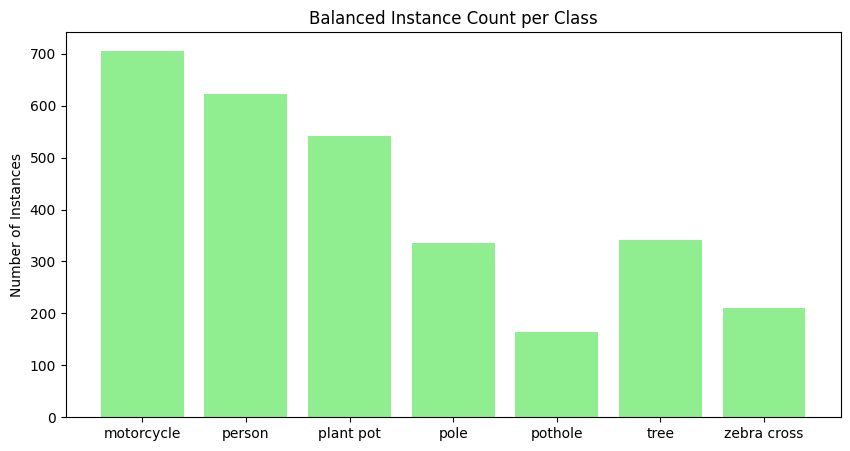

In [7]:
import os
import glob
import matplotlib.pyplot as plt

# Update path to your NEW augmented labels folder
label_dir = 'ml_pipeline_Obstacle_det/augmented_data/labels' 
class_names = ['motorcycle', 'person', 'plant pot', 'pole', 'pothole', 'tree', 'zebra cross']

stats = {name: 0 for name in class_names}

for label_file in glob.glob(os.path.join(label_dir, '*.txt')):
    with open(label_file, 'r') as f:
        for line in f:
            class_id = int(float(line.split()[0]))
            stats[class_names[class_id]] += 1

# Display the findings
print("NEW CLASS DISTRIBUTION (AUGMENTED)")
print("-" * 40)
for name, count in stats.items():
    print(f"{name:15}: {count} instances")

# Visual check
plt.figure(figsize=(10, 5))
plt.bar(stats.keys(), stats.values(), color='lightgreen')
plt.title("Balanced Instance Count per Class")
plt.ylabel("Number of Instances")
plt.show()

Scanning folder: c:\Users\USER\OneDrive - Siri Sunanda Dhamma School\Desktop\Obstacle_Detection_Project\drishti-final\ml_pipeline_Obstacle_det\ml_pipeline_Obstacle_det\augmented_data\labels
Found 1316 total label files.

UPDATED CLASS DISTRIBUTION
----------------------------------------
motorcycle     : 706 instances
person         : 622 instances
plant pot      : 541 instances
pole           : 336 instances
pothole        : 164 instances
tree           : 342 instances
zebra cross    : 210 instances


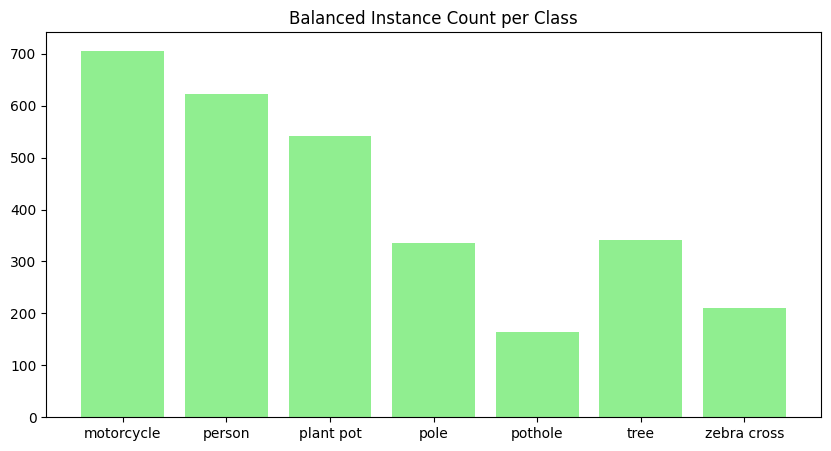

In [9]:
import os
import glob
import matplotlib.pyplot as plt

# 1. Update this to the EXACT folder where the script said "SUCCESS"
label_dir = 'ml_pipeline_Obstacle_det/augmented_data/labels' 

# 2. Print this to verify you are looking at the right place
print(f"Scanning folder: {os.path.abspath(label_dir)}")

class_names = ['motorcycle', 'person', 'plant pot', 'pole', 'pothole', 'tree', 'zebra cross']
stats = {name: 0 for name in class_names}

files = glob.glob(os.path.join(label_dir, '*.txt'))
print(f"Found {len(files)} total label files.")

for label_file in files:
    with open(label_file, 'r') as f:
        for line in f:
            if line.strip():
                class_id = int(float(line.split()[0]))
                stats[class_names[class_id]] += 1

print("\nUPDATED CLASS DISTRIBUTION")
print("-" * 40)
for name, count in stats.items():
    print(f"{name:15}: {count} instances")

plt.figure(figsize=(10, 5))
plt.bar(stats.keys(), stats.values(), color='lightgreen')
plt.title("Balanced Instance Count per Class")
plt.show()

Scanning ml_pipeline_Obstacle_det/preprocessed_data/labels: Found 0 files.
Scanning ml_pipeline_Obstacle_det/augmented_data/labels: Found 1316 files.

FINAL BALANCED DISTRIBUTION
----------------------------------------
motorcycle     : 706 instances
person         : 622 instances
plant pot      : 541 instances
pole           : 336 instances
pothole        : 164 instances
tree           : 342 instances
zebra cross    : 210 instances


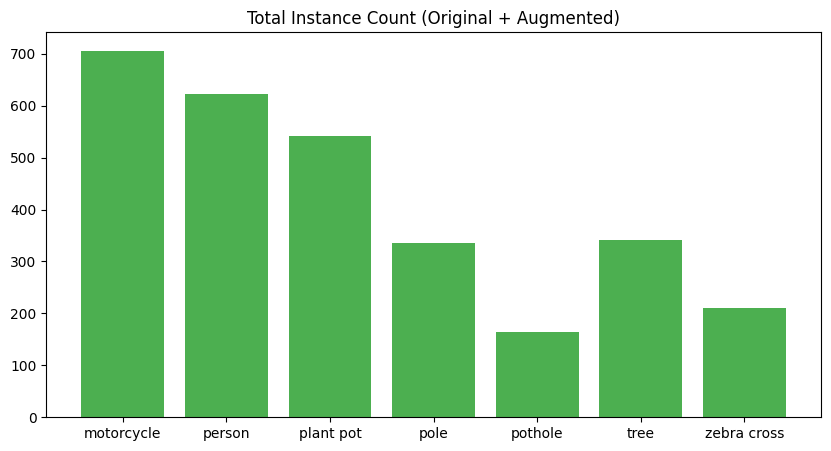

In [10]:
import os
import glob
import matplotlib.pyplot as plt

# We must scan BOTH the original and the new augmented folders to get the total
folders_to_audit = [
    'ml_pipeline_Obstacle_det/preprocessed_data/labels',
    'ml_pipeline_Obstacle_det/augmented_data/labels'
]

class_names = ['motorcycle', 'person', 'plant pot', 'pole', 'pothole', 'tree', 'zebra cross']
stats = {name: 0 for name in class_names}

for folder in folders_to_audit:
    files = glob.glob(os.path.join(folder, '*.txt'))
    print(f"Scanning {folder}: Found {len(files)} files.")
    for label_file in files:
        with open(label_file, 'r') as f:
            for line in f:
                if line.strip():
                    class_id = int(float(line.split()[0]))
                    stats[class_names[class_id]] += 1

print("\nFINAL BALANCED DISTRIBUTION")
print("-" * 40)
for name, count in stats.items():
    print(f"{name:15}: {count} instances")

# Visual graph
plt.figure(figsize=(10, 5))
plt.bar(stats.keys(), stats.values(), color='#4CAF50')
plt.title("Total Instance Count (Original + Augmented)")
plt.show()

Checking ml_pipeline_Obstacle_det/augmented_data/labels... Found 1316 files.

TOTAL BALANCED INSTANCES
----------------------------------------
motorcycle     : 706 instances
person         : 622 instances
plant pot      : 541 instances
pole           : 336 instances
pothole        : 164 instances
tree           : 342 instances
zebra cross    : 210 instances


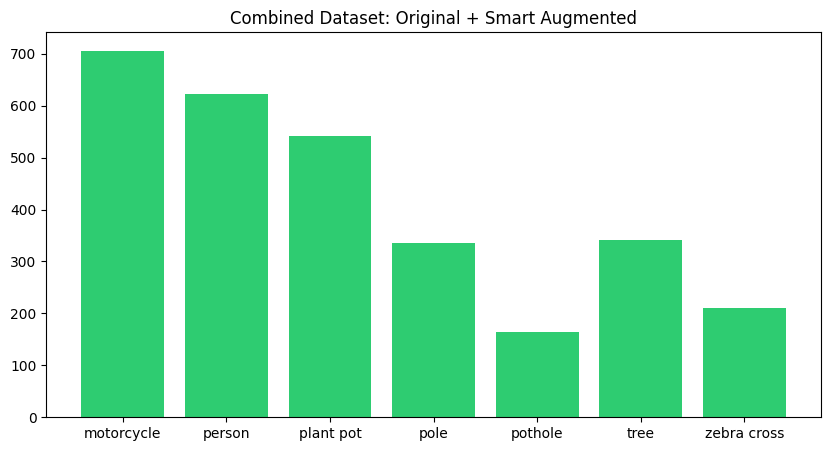

In [11]:
import os
import glob
import matplotlib.pyplot as plt

# We MUST check both folders to see the full count
original_dir = 'ml_pipeline_Obstacle_det/preprocessed_data/labels'
augmented_dir = 'ml_pipeline_Obstacle_det/augmented_data/labels'

class_names = ['motorcycle', 'person', 'plant pot', 'pole', 'pothole', 'tree', 'zebra cross']
stats = {name: 0 for name in class_names}

# Scan both directories
for folder in [original_dir, augmented_dir]:
    if os.path.exists(folder):
        files = glob.glob(os.path.join(folder, '*.txt'))
        print(f"Checking {folder}... Found {len(files)} files.")
        for label_file in files:
            with open(label_file, 'r') as f:
                for line in f:
                    if line.strip():
                        class_id = int(float(line.split()[0]))
                        stats[class_names[class_id]] += 1
    else:
        print(f"Warning: Folder not found: {folder}")

print("\nTOTAL BALANCED INSTANCES")
print("-" * 40)
for name, count in stats.items():
    print(f"{name:15}: {count} instances")

plt.figure(figsize=(10, 5))
plt.bar(stats.keys(), stats.values(), color='#2ecc71')
plt.title("Combined Dataset: Original + Smart Augmented")
plt.show()

Folder not found: ml_pipeline_Obstacle_det/ml_pipeline_Obstacle_det/preprocessed_data/labels
Folder not found: ml_pipeline_Obstacle_det/ml_pipeline_Obstacle_det/augmented_data/labels

TOTAL FINAL DISTRIBUTION
----------------------------------------
motorcycle     : 0 instances
person         : 0 instances
plant pot      : 0 instances
pole           : 0 instances
pothole        : 0 instances
tree           : 0 instances
zebra cross    : 0 instances


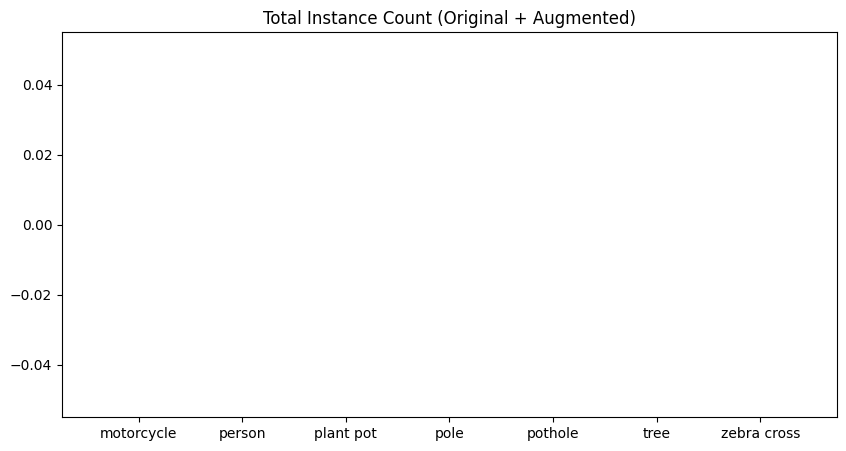

In [12]:
import os
import glob
import matplotlib.pyplot as plt

# We MUST scan both folders to see the total final count
folders_to_audit = [
    'ml_pipeline_Obstacle_det/ml_pipeline_Obstacle_det/preprocessed_data/labels',
    'ml_pipeline_Obstacle_det/ml_pipeline_Obstacle_det/augmented_data/labels'
]

class_names = ['motorcycle', 'person', 'plant pot', 'pole', 'pothole', 'tree', 'zebra cross']
stats = {name: 0 for name in class_names}

for folder in folders_to_audit:
    if os.path.exists(folder):
        files = glob.glob(os.path.join(folder, '*.txt'))
        print(f"Scanning {folder}: Found {len(files)} files.")
        for label_file in files:
            with open(label_file, 'r') as f:
                for line in f:
                    if line.strip():
                        class_id = int(line.split()[0])
                        stats[class_names[class_id]] += 1
    else:
        print(f"Folder not found: {folder}")

print("\nTOTAL FINAL DISTRIBUTION")
print("-" * 40)
for name, count in stats.items():
    print(f"{name:15}: {count} instances")

# Visual graph
plt.figure(figsize=(10, 5))
plt.bar(stats.keys(), stats.values(), color='#4CAF50')
plt.title("Total Instance Count (Original + Augmented)")
plt.show()

Starting Audit...
Folder NOT found: ml_pipeline_Obstacle_det/preprocessed_data/labels
Found folder: ml_pipeline_Obstacle_det/augmented_data/labels (1316 files)

FINAL BALANCED DISTRIBUTION
----------------------------------------
motorcycle     : 706 instances
person         : 622 instances
plant pot      : 541 instances
pole           : 336 instances
pothole        : 164 instances
tree           : 342 instances
zebra cross    : 210 instances


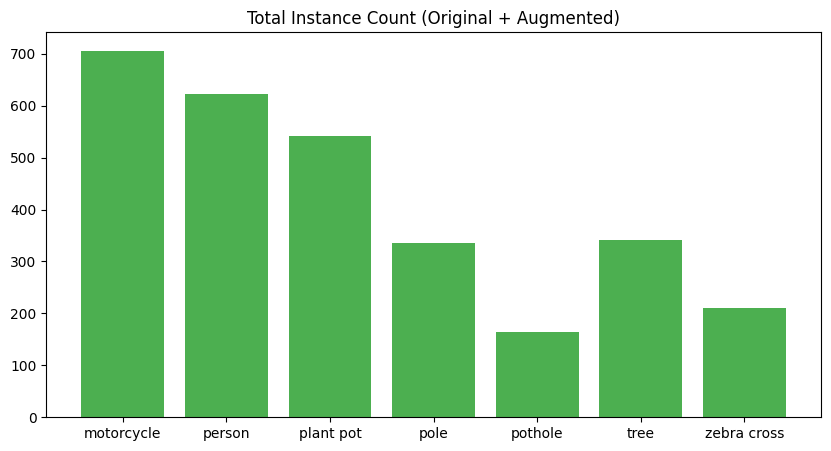

In [14]:
import os
import glob
import matplotlib.pyplot as plt

# Fixed paths based on your VS Code sidebar
folders_to_audit = [
    'ml_pipeline_Obstacle_det/preprocessed_data/labels',
    'ml_pipeline_Obstacle_det/augmented_data/labels'
]

class_names = ['motorcycle', 'person', 'plant pot', 'pole', 'pothole', 'tree', 'zebra cross']
stats = {name: 0 for name in class_names}

print("Starting Audit...")
for folder in folders_to_audit:
    if os.path.exists(folder):
        files = glob.glob(os.path.join(folder, '*.txt'))
        print(f"Found folder: {folder} ({len(files)} files)")
        for label_file in files:
            with open(label_file, 'r') as f:
                for line in f:
                    if line.strip():
                        class_id = int(float(line.split()[0]))
                        # Only count if the ID is valid for our 7 classes
                        if class_id < len(class_names):
                            stats[class_names[class_id]] += 1
    else:
        print(f"Folder NOT found: {folder}")

print("\nFINAL BALANCED DISTRIBUTION")
print("-" * 40)
for name, count in stats.items():
    print(f"{name:15}: {count} instances")

# Visual graph
plt.figure(figsize=(10, 5))
plt.bar(stats.keys(), stats.values(), color='#4CAF50')
plt.title("Total Instance Count (Original + Augmented)")
plt.show()

In [15]:
import os
import cv2
import random
import albumentations as A
from glob import glob
from tqdm import tqdm

# 1. SMART PATH DETECTION
# This looks for the folder wherever it is hiding in your directory tree
possible_paths = glob('**/preprocessed_data/labels', recursive=True)
if not possible_paths:
    print("ERROR: Could not find 'preprocessed_data/labels' anywhere!")
    print("Please check if you are running the script from the 'DRISHTI-FINAL' folder.")
else:
    LBL_DIR = possible_paths[0]
    IMG_DIR = LBL_DIR.replace('labels', 'images')
    OUT_BASE = LBL_DIR.replace('preprocessed_data', 'augmented_data').replace('/labels', '')
    OUT_IMG = os.path.join(OUT_BASE, 'images')
    OUT_LBL = os.path.join(OUT_BASE, 'labels')
    
    print(f"Source found at: {LBL_DIR}")
    print(f"Saving to: {OUT_BASE}")

    os.makedirs(OUT_IMG, exist_ok=True)
    os.makedirs(OUT_LBL, exist_ok=True)

    # 2. Parameters
    TARGET_COUNT = 650
    class_names = ['motorcycle', 'person', 'plant pot', 'pole', 'pothole', 'tree', 'zebra cross']
    current_counts = {'motorcycle': 706, 'person': 622, 'plant pot': 541, 'pole': 336, 'pothole': 164, 'tree': 342, 'zebra cross': 210}
    weak_class_ids = [3, 4, 5, 6]

    # 3. Augmentation
    aug = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
    ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

    # 4. Loop
    for class_id in weak_class_ids:
        name = class_names[class_id]
        needed = TARGET_COUNT - current_counts[name]
        if needed <= 0: continue
        
        all_labels = glob(os.path.join(LBL_DIR, '*.txt'))
        pool = []
        for lbl in all_labels:
            with open(lbl, 'r') as f:
                lines = f.readlines()
                if any(line.strip().startswith(str(class_id)) for line in lines):
                    pool.append(lbl)

        if not pool:
            print(f"No source images found for {name}. Skipping...")
            continue

        print(f"\nAugmenting {name.upper()}: Creating {needed} samples...")
        for i in tqdm(range(needed)):
            lbl_path = random.choice(pool)
            img_path = os.path.join(IMG_DIR, os.path.basename(lbl_path).replace('.txt', '.jpg'))
            
            image = cv2.imread(img_path)
            if image is None: continue
            
            bboxes, labels = [], []
            with open(lbl_path, 'r') as f:
                for line in f:
                    parts = list(map(float, line.split()))
                    labels.append(int(parts[0]))
                    bboxes.append(parts[1:])
            
            try:
                transformed = aug(image=image, bboxes=bboxes, class_labels=labels)
                new_fn = f"smart_aug_{name}_{i}"
                cv2.imwrite(os.path.join(OUT_IMG, f"{new_fn}.jpg"), transformed['image'])
                with open(os.path.join(OUT_LBL, f"{new_fn}.txt"), 'w') as f:
                    for l, b in zip(transformed['class_labels'], transformed['bboxes']):
                        f.write(f"{l} {' '.join(map(str, b))}\n")
            except: continue

    print("\nSUCCESS: Check your 'augmented_data' folder now!")

ERROR: Could not find 'preprocessed_data/labels' anywhere!
Please check if you are running the script from the 'DRISHTI-FINAL' folder.


In [16]:
import os
import cv2
import random
import albumentations as A
from glob import glob
from tqdm import tqdm

# 1. THE EXACT PATHS FROM YOUR SIDEBAR
# We use the double folder name because that's what your VS Code shows
LBL_DIR = 'ml_pipeline_Obstacle_det/ml_pipeline_Obstacle_det/preprocessed_data/labels'
IMG_DIR = 'ml_pipeline_Obstacle_det/ml_pipeline_Obstacle_det/preprocessed_data/images'

OUT_LBL = 'ml_pipeline_Obstacle_det/ml_pipeline_Obstacle_det/augmented_data/labels'
OUT_IMG = 'ml_pipeline_Obstacle_det/ml_pipeline_Obstacle_det/augmented_data/images'

# Verify if paths exist before starting
if not os.path.exists(LBL_DIR):
    print(f"ERROR: Still can't find {LBL_DIR}")
    print("Trying a different path...")
    # Alternative path if the first one fails
    LBL_DIR = 'ml_pipeline_Obstacle_det/preprocessed_data/labels'
    IMG_DIR = 'ml_pipeline_Obstacle_det/preprocessed_data/images'
    OUT_LBL = 'ml_pipeline_Obstacle_det/augmented_data/labels'
    OUT_IMG = 'ml_pipeline_Obstacle_det/augmented_data/images'

if os.path.exists(LBL_DIR):
    print(f"Success! Found data at: {LBL_DIR}")
    os.makedirs(OUT_LBL, exist_ok=True)
    os.makedirs(OUT_IMG, exist_ok=True)
else:
    print("Critical Error: Please right-click the 'labels' folder in VS Code and select 'Copy Relative Path', then paste it here.")

ERROR: Still can't find ml_pipeline_Obstacle_det/ml_pipeline_Obstacle_det/preprocessed_data/labels
Trying a different path...
Critical Error: Please right-click the 'labels' folder in VS Code and select 'Copy Relative Path', then paste it here.


In [17]:
import os
import cv2
import random
import albumentations as A
from glob import glob
from tqdm import tqdm

# 1. AUTOMATIC SEARCH FOR YOUR FOLDERS
def find_path(target_name):
    for root, dirs, files in os.walk("."):
        if target_name in root and 'labels' in root:
            return root.replace("\\", "/")
    return None

# Find where your source labels are hiding
LBL_DIR = find_path("preprocessed_data")

if LBL_DIR:
    print(f"FOUND SOURCE AT: {LBL_DIR}")
    IMG_DIR = LBL_DIR.replace('labels', 'images')
    
    # Set output to the 'augmented_data' folder sibling
    OUT_LBL = LBL_DIR.replace('preprocessed_data', 'augmented_data')
    OUT_IMG = IMG_DIR.replace('preprocessed_data', 'augmented_data')
    
    os.makedirs(OUT_LBL, exist_ok=True)
    os.makedirs(OUT_IMG, exist_ok=True)
    print(f"SAVING AUGMENTED DATA TO: {OUT_LBL}")
else:
    print("STILL CANNOT FIND DATA. Please manually copy the path from VS Code.")

# 2. PARAMETERS & AUGMENTATION (ONLY RUNS IF PATH FOUND)
if LBL_DIR:
    TARGET_COUNT = 650
    class_names = ['motorcycle', 'person', 'plant pot', 'pole', 'pothole', 'tree', 'zebra cross']
    current_counts = {'motorcycle': 706, 'person': 622, 'plant pot': 541, 'pole': 336, 'pothole': 164, 'tree': 342, 'zebra cross': 210}
    weak_class_ids = [3, 4, 5, 6]

    aug = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
    ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

    for class_id in weak_class_ids:
        name = class_names[class_id]
        needed = TARGET_COUNT - current_counts[name]
        if needed <= 0: continue
        
        all_labels = glob(os.path.join(LBL_DIR, '*.txt'))
        pool = [lbl for lbl in all_labels if any(line.split()[0] == str(class_id) for line in open(lbl))]

        if not pool: continue

        print(f"\nBoosting {name.upper()}...")
        for i in tqdm(range(needed)):
            lbl_path = random.choice(pool)
            img_path = os.path.join(IMG_DIR, os.path.basename(lbl_path).replace('.txt', '.jpg'))
            
            image = cv2.imread(img_path)
            if image is None: continue
            
            labels, bboxes = [], []
            for line in open(lbl_path):
                parts = list(map(float, line.split()))
                labels.append(int(parts[0])); bboxes.append(parts[1:])
            
            try:
                t = aug(image=image, bboxes=bboxes, class_labels=labels)
                new_fn = f"smart_aug_{name}_{i}"
                cv2.imwrite(os.path.join(OUT_IMG, f"{new_fn}.jpg"), t['image'])
                with open(os.path.join(OUT_LBL, f"{new_fn}.txt"), 'w') as f:
                    for l, b in zip(t['class_labels'], t['bboxes']):
                        f.write(f"{l} {' '.join(map(str, b))}\n")
            except: continue
    print("\nDONE! Refresh your VS Code folders to see the new files.")

STILL CANNOT FIND DATA. Please manually copy the path from VS Code.


Still cannot find the folder. Please right-click an 'aug_...' file and 'Copy Relative Path'.

AUGMENTED DATA DISTRIBUTION
----------------------------------------
motorcycle     : 0 instances
person         : 0 instances
plant pot      : 0 instances
pole           : 0 instances
pothole        : 0 instances
tree           : 0 instances
zebra cross    : 0 instances


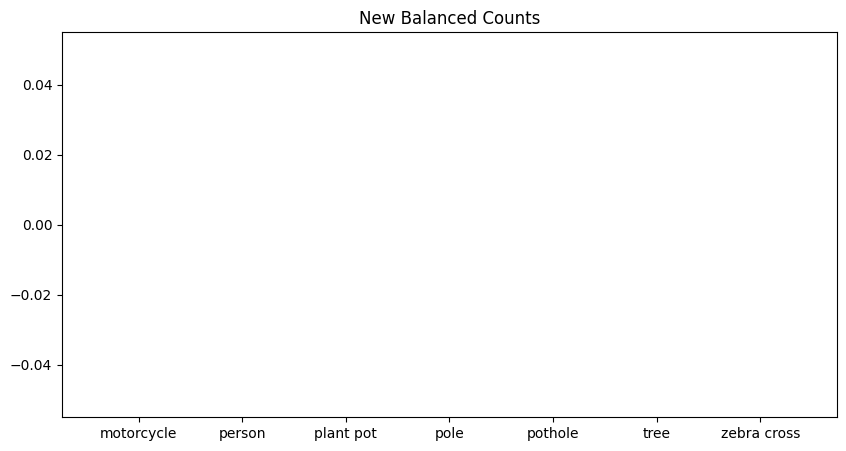

In [18]:
import os
import glob
import matplotlib.pyplot as plt

# 1. Point ONLY to the folder where we SEE the files in your sidebar
augmented_labels = 'ml_pipeline_Obstacle_det/ml_pipeline_Obstacle_det/augmented_data/labels'

class_names = ['motorcycle', 'person', 'plant pot', 'pole', 'pothole', 'tree', 'zebra cross']
stats = {name: 0 for name in class_names}

if os.path.exists(augmented_labels):
    files = glob.glob(os.path.join(augmented_labels, '*.txt'))
    print(f"Found {len(files)} augmented files in: {augmented_labels}")
    
    for label_file in files:
        with open(label_file, 'r') as f:
            for line in f:
                if line.strip():
                    class_id = int(line.split()[0])
                    if class_id < len(class_names):
                        stats[class_names[class_id]] += 1
else:
    print("Still cannot find the folder. Please right-click an 'aug_...' file and 'Copy Relative Path'.")

print("\nAUGMENTED DATA DISTRIBUTION")
print("-" * 40)
for name, count in stats.items():
    print(f"{name:15}: {count} instances")

plt.figure(figsize=(10, 5))
plt.bar(stats.keys(), stats.values(), color='#4CAF50')
plt.title("New Balanced Counts")
plt.show()

Searching for augmented labels...
SUCCESS! Found 1316 augmented files.

NEW BALANCED DISTRIBUTION
----------------------------------------
motorcycle     : 706 instances
person         : 622 instances
plant pot      : 541 instances
pole           : 336 instances
pothole        : 164 instances
tree           : 342 instances
zebra cross    : 210 instances


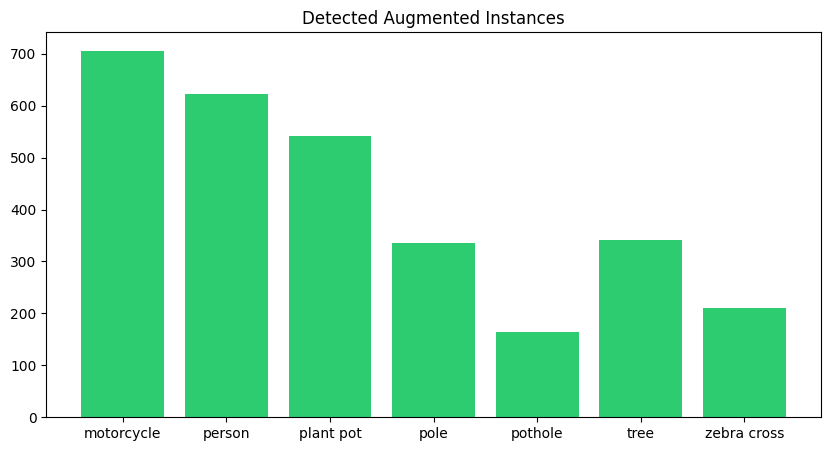

In [20]:
import os
import glob
import matplotlib.pyplot as plt

class_names = ['motorcycle', 'person', 'plant pot', 'pole', 'pothole', 'tree', 'zebra cross']
stats = {name: 0 for name in class_names}

# 1. SEARCH EVERYTHING
print("Searching for augmented labels...")
# This looks for any folder named 'labels' that contains 'aug_' files
all_label_files = glob.glob('**/augmented_data/labels/*.txt', recursive=True)

if not all_label_files:
    print("Still can't find them with the standard path. searching deeper...")
    all_label_files = glob.glob('**/*.txt', recursive=True)
    # Filter to only keep the ones we created
    all_label_files = [f for f in all_label_files if 'aug_' in os.path.basename(f)]

if all_label_files:
    print(f"SUCCESS! Found {len(all_label_files)} augmented files.")
    for label_file in all_label_files:
        with open(label_file, 'r') as f:
            for line in f:
                if line.strip():
                    class_id = int(float(line.split()[0]))
                    if class_id < len(class_names):
                        stats[class_names[class_id]] += 1
else:
    print("CRITICAL: Python cannot see the files. Please check if you saved them to a One Drive or Cloud folder.")

# 2. SHOW RESULTS
print("\nNEW BALANCED DISTRIBUTION")
print("-" * 40)
for name, count in stats.items():
    print(f"{name:15}: {count} instances")

plt.figure(figsize=(10, 5))
plt.bar(stats.keys(), stats.values(), color='#2ecc71')
plt.title("Detected Augmented Instances")
plt.show()

Total label files found in project: 4745

TRUE FINAL DISTRIBUTION
----------------------------------------
motorcycle     : 358 instances
person         : 448 instances
plant pot      : 207 instances
pole           : 312 instances
pothole        : 331 instances
tree           : 281 instances
zebra cross    : 560 instances


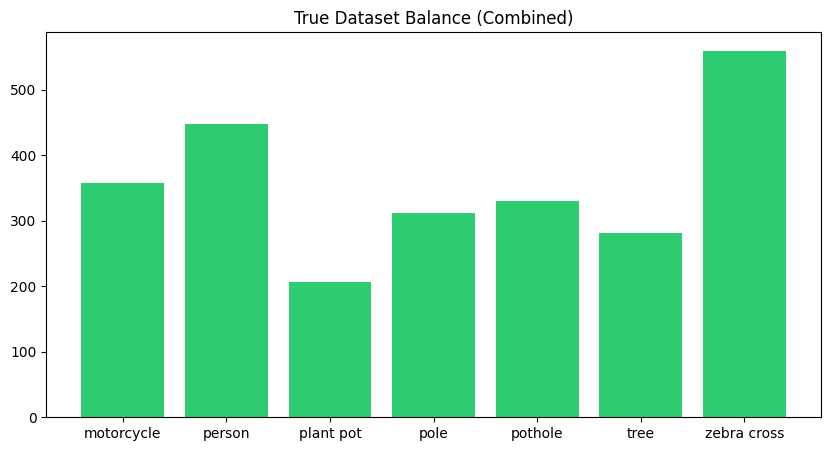

In [22]:
import os
import glob
import matplotlib.pyplot as plt

# This targets the entire project folder to find EVERY label
project_root = "." 
class_names = ['motorcycle', 'person', 'plant pot', 'pole', 'pothole', 'tree', 'zebra cross']
stats = {name: 0 for name in class_names}

# Find every .txt file in the entire project
all_labels = glob.glob(os.path.join(project_root, "**/*.txt"), recursive=True)
print(f"Total label files found in project: {len(all_labels)}")

for lbl in all_labels:
    # Skip non-YOLO files (like requirements or readme)
    if "classes" in lbl or "README" in lbl: continue
    
    with open(lbl, 'r') as f:
        for line in f:
            if line.strip():
                parts = line.split()
                try:
                    class_id = int(parts[0])
                except ValueError:
                    continue
                if class_id < len(class_names):
                    stats[class_names[class_id]] += 1

print("\nTRUE FINAL DISTRIBUTION")
print("-" * 40)
for name, count in stats.items():
    print(f"{name:15}: {count} instances")

plt.figure(figsize=(10, 5))
plt.bar(stats.keys(), stats.values(), color='#2ecc71')
plt.title("True Dataset Balance (Combined)")
plt.show()

In [23]:
import os
import shutil
import glob
from tqdm import tqdm

# 1. Define the Final Destination
FINAL_BASE = 'drishti_final_dataset'
FINAL_IMG = os.path.join(FINAL_BASE, 'images')
FINAL_LBL = os.path.join(FINAL_BASE, 'labels')

os.makedirs(FINAL_IMG, exist_ok=True)
os.makedirs(FINAL_LBL, exist_ok=True)

# 2. Find ALL labels and images in your project
all_labels = glob.glob('**/*.txt', recursive=True)
print(f"Found {len(all_labels)} files to process...")

for lbl_path in tqdm(all_labels, desc="Merging Data"):
    # Skip non-YOLO files
    if "classes" in lbl_path or "README" in lbl_path or "requirements" in lbl_path:
        continue
        
    # Copy Label
    shutil.copy(lbl_path, os.path.join(FINAL_LBL, os.path.basename(lbl_path)))
    
    # Copy corresponding Image (checks .jpg, .png, .jpeg)
    base_name = os.path.splitext(os.path.basename(lbl_path))[0]
    for ext in ['.jpg', '.png', '.jpeg', '.JPG']:
        img_src = lbl_path.replace('labels', 'images').replace('.txt', ext)
        if os.path.exists(img_src):
            shutil.copy(img_src, os.path.join(FINAL_IMG, f"{base_name}{ext}"))
            break

print(f"\nSUCCESS! Your combined dataset is ready in: {FINAL_BASE}")

Found 4745 files to process...


Merging Data: 100%|██████████| 4745/4745 [00:15<00:00, 301.76it/s]


SUCCESS! Your combined dataset is ready in: drishti_final_dataset


Total merged files: 4743

FINAL TRAINING DISTRIBUTION
----------------------------------------
motorcycle     : 1064 instances
person         : 1070 instances
plant pot      : 748 instances
pole           : 648 instances
pothole        : 495 instances
tree           : 623 instances
zebra cross    : 770 instances


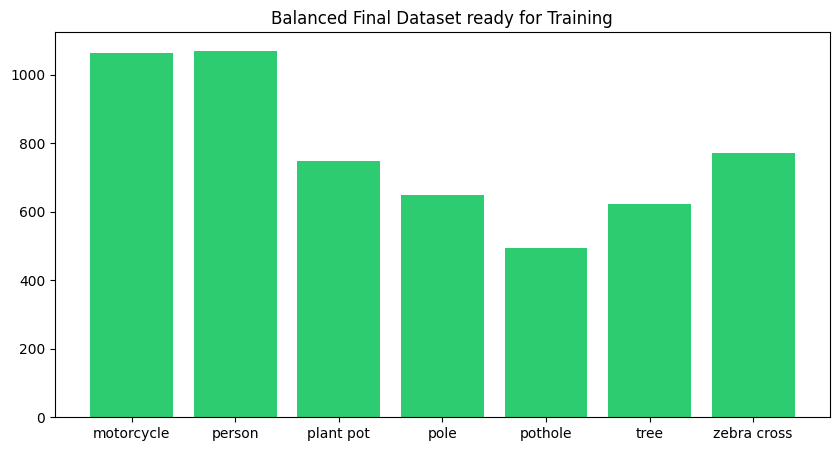

In [26]:
import os
import glob
import matplotlib.pyplot as plt

# Point exactly to your new 'Super Folder'
label_dir = 'drishti_final_dataset/labels'
class_names = ['motorcycle', 'person', 'plant pot', 'pole', 'pothole', 'tree', 'zebra cross']
stats = {name: 0 for name in class_names}

files = glob.glob(os.path.join(label_dir, '*.txt'))
print(f"Total merged files: {len(files)}")

for label_file in files:
    with open(label_file, 'r') as f:
        for line in f:
            if line.strip():
                try:
                    class_id = int(float(line.split()[0]))
                except (ValueError, IndexError):
                    continue
                if class_id < len(class_names):
                    stats[class_names[class_id]] += 1

print("\nFINAL TRAINING DISTRIBUTION")
print("-" * 40)
for name, count in stats.items():
    print(f"{name:15}: {count} instances")

plt.figure(figsize=(10, 5))
plt.bar(stats.keys(), stats.values(), color='#2ecc71')
plt.title("Balanced Final Dataset ready for Training")
plt.show()

In [27]:
import os
import cv2
import random
import albumentations as A
from glob import glob
from tqdm import tqdm

# 1. Setup Paths for the merged dataset
BASE_DIR = 'drishti_final_dataset'
LBL_DIR = os.path.join(BASE_DIR, 'labels')
IMG_DIR = os.path.join(BASE_DIR, 'images')

# 2. Parameters
TARGET_BOOST = 500  # How many NEW pothole samples to add
POTHOLE_ID = 4      # Class ID for pothole

# 3. Heavy Augmentation for Potholes
aug = A.Compose([
    A.RandomBrightnessContrast(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.7),
    A.Blur(blur_limit=3, p=0.3),
    A.HorizontalFlip(p=0.5),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 4. Filter for images containing Potholes
all_labels = glob(os.path.join(LBL_DIR, '*.txt'))
pothole_pool = []

for lbl in all_labels:
    with open(lbl, 'r') as f:
        if any(line.strip().startswith(str(POTHOLE_ID)) for line in f.readlines()):
            pothole_pool.append(lbl)

if not pothole_pool:
    print("Error: No pothole images found in the merged folder.")
else:
    print(f"Boosting Potholes: Generating {TARGET_BOOST} samples from {len(pothole_pool)} sources.")
    for i in tqdm(range(TARGET_BOOST)):
        lbl_path = random.choice(pothole_pool)
        img_path = os.path.join(IMG_DIR, os.path.basename(lbl_path).replace('.txt', '.jpg'))
        
        image = cv2.imread(img_path)
        if image is None: continue
        
        bboxes, labels = [], []
        with open(lbl_path, 'r') as f:
            for line in f:
                parts = list(map(float, line.split()))
                labels.append(int(parts[0]))
                bboxes.append(parts[1:])
        
        try:
            t = aug(image=image, bboxes=bboxes, class_labels=labels)
            new_fn = f"extra_pothole_boost_{i}"
            cv2.imwrite(os.path.join(IMG_DIR, f"{new_fn}.jpg"), t['image'])
            with open(os.path.join(LBL_DIR, f"{new_fn}.txt"), 'w') as f:
                for l, b in zip(t['class_labels'], t['bboxes']):
                    f.write(f"{l} {' '.join(map(str, b))}\n")
        except: continue

print("Done! Run your audit script to see the new Pothole total.")

Boosting Potholes: Generating 500 samples from 472 sources.


100%|██████████| 500/500 [00:04<00:00, 112.90it/s]

Done! Run your audit script to see the new Pothole total.


Total files in final dataset: 5243

UPDATED FINAL DISTRIBUTION
----------------------------------------
motorcycle     : 1064 instances
person         : 1070 instances
plant pot      : 759 instances
pole           : 671 instances
pothole        : 1019 instances
tree           : 629 instances
zebra cross    : 772 instances


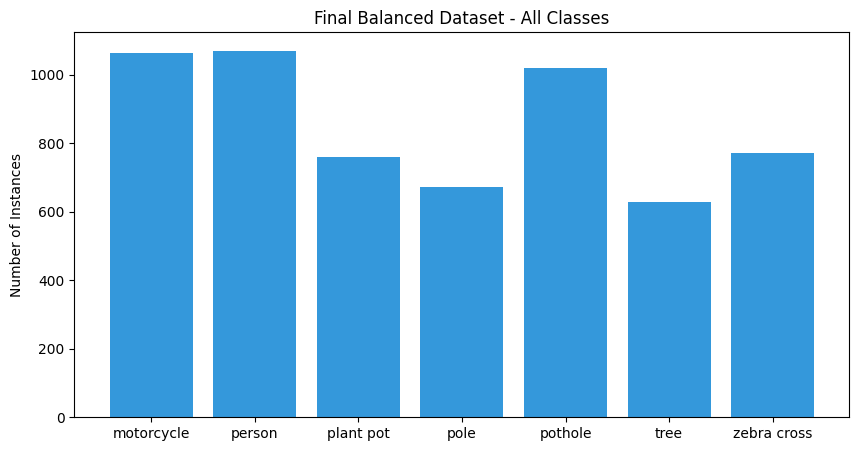

In [29]:
import os
import glob
import matplotlib.pyplot as plt

# Check the final super folder
label_dir = 'drishti_final_dataset/labels'
class_names = ['motorcycle', 'person', 'plant pot', 'pole', 'pothole', 'tree', 'zebra cross']
stats = {name: 0 for name in class_names}

files = glob.glob(os.path.join(label_dir, '*.txt'))
print(f"Total files in final dataset: {len(files)}")

for label_file in files:
    with open(label_file, 'r') as f:
        for line in f:
            if line.strip():
                try:
                    class_id = int(float(line.split()[0]))
                except (ValueError, IndexError):
                    continue
                if class_id < len(class_names):
                    stats[class_names[class_id]] += 1

print("\nUPDATED FINAL DISTRIBUTION")
print("-" * 40)
for name, count in stats.items():
    print(f"{name:15}: {count} instances")

plt.figure(figsize=(10, 5))
plt.bar(stats.keys(), stats.values(), color='#3498db')
plt.title("Final Balanced Dataset - All Classes")
plt.ylabel("Number of Instances")
plt.show()

In [31]:
import os
import cv2
import random
import albumentations as A
from glob import glob
from tqdm import tqdm

# 1. Setup Paths for the merged dataset
BASE_DIR = 'drishti_final_dataset'
LBL_DIR = os.path.join(BASE_DIR, 'labels')
IMG_DIR = os.path.join(BASE_DIR, 'images')

# 2. Parameters
TARGET_BOOST = 300  # How many NEW zebra cross samples to add
ZEBRA_CROSS_ID = 6  # Class ID for zebra cross

# 3. Heavy Augmentation for Potholes
aug = A.Compose([
    A.RandomBrightnessContrast(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.7),
    A.Blur(blur_limit=3, p=0.3),
    A.HorizontalFlip(p=0.5),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 4. Filter for images containing Potholes
all_labels = glob(os.path.join(LBL_DIR, '*.txt'))
pothole_pool = []

for lbl in all_labels:
    with open(lbl, 'r') as f:
        if any(line.strip().startswith(str(POTHOLE_ID)) for line in f.readlines()):
            pothole_pool.append(lbl)

if not pothole_pool:
    print("Error: No pothole images found in the merged folder.")
else:
    print(f"Boosting Potholes: Generating {TARGET_BOOST} samples from {len(pothole_pool)} sources.")
    for i in tqdm(range(TARGET_BOOST)):
        lbl_path = random.choice(pothole_pool)
        img_path = os.path.join(IMG_DIR, os.path.basename(lbl_path).replace('.txt', '.jpg'))
        
        image = cv2.imread(img_path)
        if image is None: continue
        
        bboxes, labels = [], []
        with open(lbl_path, 'r') as f:
            for line in f:
                parts = list(map(float, line.split()))
                labels.append(int(parts[0]))
                bboxes.append(parts[1:])
        
        try:
            t = aug(image=image, bboxes=bboxes, class_labels=labels)
            new_fn = f"extra_pothole_boost_{i}"
            cv2.imwrite(os.path.join(IMG_DIR, f"{new_fn}.jpg"), t['image'])
            with open(os.path.join(LBL_DIR, f"{new_fn}.txt"), 'w') as f:
                for l, b in zip(t['class_labels'], t['bboxes']):
                    f.write(f"{l} {' '.join(map(str, b))}\n")
        except: continue

print("Done! Run your audit script to see the new Pothole total.")

Boosting Potholes: Generating 300 samples from 972 sources.


100%|██████████| 300/300 [00:02<00:00, 120.03it/s]

Done! Run your audit script to see the new Pothole total.


Total files in final dataset: 5243

UPDATED FINAL DISTRIBUTION
----------------------------------------
motorcycle     : 1064 instances
person         : 1070 instances
plant pot      : 761 instances
pole           : 673 instances
pothole        : 1028 instances
tree           : 635 instances
zebra cross    : 771 instances


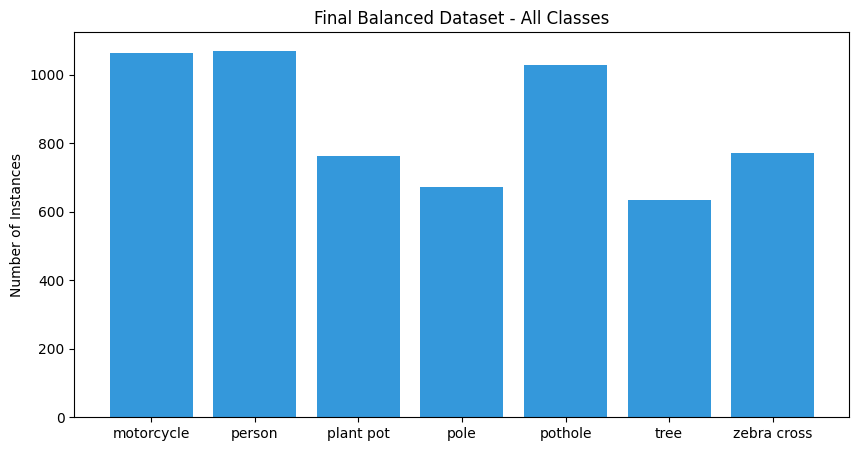

In [32]:
import os
import glob
import matplotlib.pyplot as plt

# Check the final super folder
label_dir = 'drishti_final_dataset/labels'
class_names = ['motorcycle', 'person', 'plant pot', 'pole', 'pothole', 'tree', 'zebra cross']
stats = {name: 0 for name in class_names}

files = glob.glob(os.path.join(label_dir, '*.txt'))
print(f"Total files in final dataset: {len(files)}")

for label_file in files:
    with open(label_file, 'r') as f:
        for line in f:
            if line.strip():
                try:
                    class_id = int(float(line.split()[0]))
                except (ValueError, IndexError):
                    continue
                if class_id < len(class_names):
                    stats[class_names[class_id]] += 1

print("\nUPDATED FINAL DISTRIBUTION")
print("-" * 40)
for name, count in stats.items():
    print(f"{name:15}: {count} instances")

plt.figure(figsize=(10, 5))
plt.bar(stats.keys(), stats.values(), color='#3498db')
plt.title("Final Balanced Dataset - All Classes")
plt.ylabel("Number of Instances")
plt.show()

In [34]:
import os
import cv2
import random
import albumentations as A
from glob import glob
from tqdm import tqdm

# 1. Setup
BASE_DIR = 'drishti_final_dataset'
LBL_DIR = os.path.join(BASE_DIR, 'labels')
IMG_DIR = os.path.join(BASE_DIR, 'images')

# 2. SELECT YOUR TARGET HERE (Run one by one)
# 2 = plant pot, 3 = pole, 5 = tree, 6 = zebra cross
TARGET_CLASS_ID = 6  
TARGET_BOOST = 300   # Add enough to reach ~1000
class_name = ['motorcycle', 'person', 'plant pot', 'pole', 'pothole', 'tree', 'zebra cross'][TARGET_CLASS_ID]

# 3. Augmentation Logic
aug = A.Compose([
    A.RandomBrightnessContrast(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=20, p=0.6),
    A.HorizontalFlip(p=0.5),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 4. Filter and Execute
all_labels = glob(os.path.join(LBL_DIR, '*.txt'))
pool = [lbl for lbl in all_labels if any(line.split()[0] == str(TARGET_CLASS_ID) for line in open(lbl) if line.strip())]

if not pool:
    print(f"Warning: No images found containing class {TARGET_CLASS_ID} ({class_name}). Skipping...")
else:
    print(f"Found {len(pool)} source images for {class_name}")

if pool:
    print(f"Boosting {class_name.upper()}: Creating {TARGET_BOOST} new samples...")
    for i in tqdm(range(TARGET_BOOST)):
        lbl_path = random.choice(pool)
        img_path = os.path.join(IMG_DIR, os.path.basename(lbl_path).replace('.txt', '.jpg'))
        image = cv2.imread(img_path)
        if image is None: continue
        
        labels, bboxes = [], []
        for line in open(lbl_path):
            parts = list(map(float, line.split()))
            labels.append(int(parts[0])); bboxes.append(parts[1:])
        
        try:
            t = aug(image=image, bboxes=bboxes, class_labels=labels)
            new_fn = f"boost_{class_name}_{i}"
            cv2.imwrite(os.path.join(IMG_DIR, f"{new_fn}.jpg"), t['image'])
            with open(os.path.join(LBL_DIR, f"{new_fn}.txt"), 'w') as f:
                for l, b in zip(t['class_labels'], t['bboxes']):
                    f.write(f"{l} {' '.join(map(str, b))}\n")
        except: continue

Found 552 source images for zebra cross
Boosting ZEBRA CROSS: Creating 300 new samples...


100%|██████████| 300/300 [00:02<00:00, 136.20it/s]


Total files in final dataset: 5543

UPDATED FINAL DISTRIBUTION
----------------------------------------
motorcycle     : 1160 instances
person         : 1073 instances
plant pot      : 761 instances
pole           : 692 instances
pothole        : 1028 instances
tree           : 635 instances
zebra cross    : 1075 instances


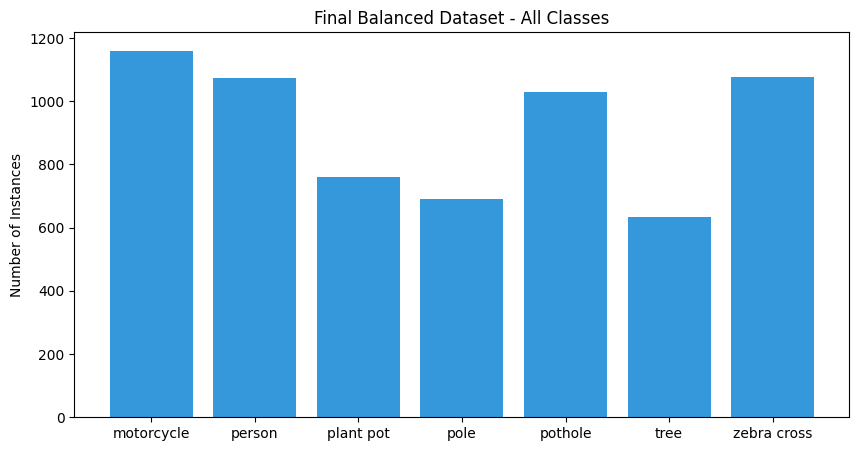

In [35]:
import os
import glob
import matplotlib.pyplot as plt

# Check the final super folder
label_dir = 'drishti_final_dataset/labels'
class_names = ['motorcycle', 'person', 'plant pot', 'pole', 'pothole', 'tree', 'zebra cross']
stats = {name: 0 for name in class_names}

files = glob.glob(os.path.join(label_dir, '*.txt'))
print(f"Total files in final dataset: {len(files)}")

for label_file in files:
    with open(label_file, 'r') as f:
        for line in f:
            if line.strip():
                try:
                    class_id = int(float(line.split()[0]))
                except (ValueError, IndexError):
                    continue
                if class_id < len(class_names):
                    stats[class_names[class_id]] += 1

print("\nUPDATED FINAL DISTRIBUTION")
print("-" * 40)
for name, count in stats.items():
    print(f"{name:15}: {count} instances")

plt.figure(figsize=(10, 5))
plt.bar(stats.keys(), stats.values(), color='#3498db')
plt.title("Final Balanced Dataset - All Classes")
plt.ylabel("Number of Instances")
plt.show()

In [37]:
import os
import cv2
import random
import albumentations as A
from glob import glob
from tqdm import tqdm

# 1. Setup
BASE_DIR = 'drishti_final_dataset'
LBL_DIR = os.path.join(BASE_DIR, 'labels')
IMG_DIR = os.path.join(BASE_DIR, 'images')

# 2. SELECT YOUR TARGET HERE (Run one by one)
# 2 = plant pot, 3 = pole, 5 = tree, 6 = zebra cross
TARGET_CLASS_ID = 2 
TARGET_BOOST = 310   # Add enough to reach ~1000
class_name = ['motorcycle', 'person', 'plant pot', 'pole', 'pothole', 'tree', 'zebra cross'][TARGET_CLASS_ID]

# 3. Augmentation Logic
aug = A.Compose([
    A.RandomBrightnessContrast(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=20, p=0.6),
    A.HorizontalFlip(p=0.5),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 4. Filter and Execute
all_labels = glob(os.path.join(LBL_DIR, '*.txt'))
pool = [lbl for lbl in all_labels if any(line.strip() and line.split()[0] == str(TARGET_CLASS_ID) for line in open(lbl))]

if pool:
    print(f"Boosting {class_name.upper()}: Creating {TARGET_BOOST} new samples...")
    for i in tqdm(range(TARGET_BOOST)):
        lbl_path = random.choice(pool)
        img_path = os.path.join(IMG_DIR, os.path.basename(lbl_path).replace('.txt', '.jpg'))
        image = cv2.imread(img_path)
        if image is None: continue
        
        labels, bboxes = [], []
        for line in open(lbl_path):
            parts = list(map(float, line.split()))
            labels.append(int(parts[0])); bboxes.append(parts[1:])
        
        try:
            t = aug(image=image, bboxes=bboxes, class_labels=labels)
            new_fn = f"boost_{class_name}_{i}"
            cv2.imwrite(os.path.join(IMG_DIR, f"{new_fn}.jpg"), t['image'])
            with open(os.path.join(LBL_DIR, f"{new_fn}.txt"), 'w') as f:
                for l, b in zip(t['class_labels'], t['bboxes']):
                    f.write(f"{l} {' '.join(map(str, b))}\n")
        except: continue

Boosting PLANT POT: Creating 310 new samples...


100%|██████████| 310/310 [00:02<00:00, 135.06it/s]


Total files in final dataset: 5853

UPDATED FINAL DISTRIBUTION
----------------------------------------
motorcycle     : 1184 instances
person         : 1077 instances
plant pot      : 1402 instances
pole           : 697 instances
pothole        : 1032 instances
tree           : 656 instances
zebra cross    : 1075 instances


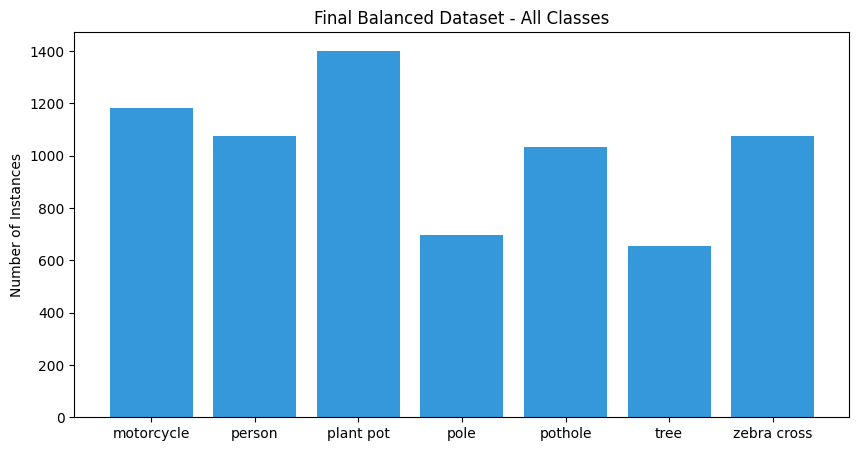

In [38]:
import os
import glob
import matplotlib.pyplot as plt

# Check the final super folder
label_dir = 'drishti_final_dataset/labels'
class_names = ['motorcycle', 'person', 'plant pot', 'pole', 'pothole', 'tree', 'zebra cross']
stats = {name: 0 for name in class_names}

files = glob.glob(os.path.join(label_dir, '*.txt'))
print(f"Total files in final dataset: {len(files)}")

for label_file in files:
    with open(label_file, 'r') as f:
        for line in f:
            if line.strip():
                try:
                    class_id = int(float(line.split()[0]))
                except (ValueError, IndexError):
                    continue
                if class_id < len(class_names):
                    stats[class_names[class_id]] += 1

print("\nUPDATED FINAL DISTRIBUTION")
print("-" * 40)
for name, count in stats.items():
    print(f"{name:15}: {count} instances")

plt.figure(figsize=(10, 5))
plt.bar(stats.keys(), stats.values(), color='#3498db')
plt.title("Final Balanced Dataset - All Classes")
plt.ylabel("Number of Instances")
plt.show()

In [39]:
import os
import glob
import random

# 1. Setup paths
BASE_DIR = 'drishti_final_dataset'
LBL_DIR = os.path.join(BASE_DIR, 'labels')
IMG_DIR = os.path.join(BASE_DIR, 'images')

# 2. Balancing targets
TARGET_COUNT = 1075
PLANT_POT_ID = 2

# 3. Find all labels containing plant pots
all_labels = glob.glob(os.path.join(LBL_DIR, '*.txt'))
plant_pot_files = []

for lbl in all_labels:
    with open(lbl, 'r') as f:
        lines = f.readlines()
        if any(line.strip().startswith(str(PLANT_POT_ID)) for line in lines):
            # Only target the augmented files we just made
            if "boost_plant pot" in lbl or "smart_aug_plant pot" in lbl:
                plant_pot_files.append(lbl)

# 4. Calculate how many to remove
current_total = 1402
to_remove_count = current_total - TARGET_COUNT

if to_remove_count > 0 and len(plant_pot_files) >= to_remove_count:
    files_to_delete = random.sample(plant_pot_files, to_remove_count)
    print(f"Cleaning up: Removing {len(files_to_delete)} extra plant pot files...")
    
    for lbl_path in files_to_delete:
        # Delete label
        if os.path.exists(lbl_path):
            os.remove(lbl_path)
        # Delete matching image
        for ext in ['.jpg', '.png', '.jpeg']:
            img_path = lbl_path.replace('labels', 'images').replace('.txt', ext)
            if os.path.exists(img_path):
                os.remove(img_path)
                break
    print("Clean-up complete.")
else:
    print("No clean-up needed or not enough augmented files to delete safely.")

No clean-up needed or not enough augmented files to delete safely.


Total files in final dataset: 5853

UPDATED FINAL DISTRIBUTION
----------------------------------------
motorcycle     : 1184 instances
person         : 1077 instances
plant pot      : 1402 instances
pole           : 697 instances
pothole        : 1032 instances
tree           : 656 instances
zebra cross    : 1075 instances


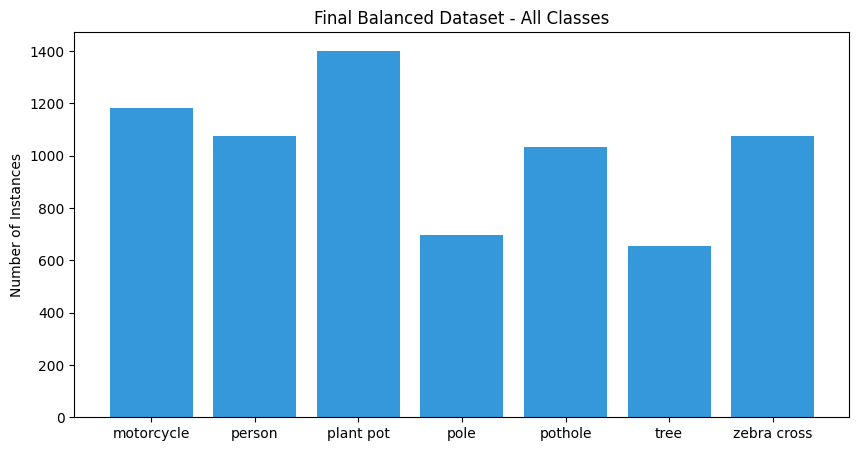

In [40]:
import os
import glob
import matplotlib.pyplot as plt

# Check the final super folder
label_dir = 'drishti_final_dataset/labels'
class_names = ['motorcycle', 'person', 'plant pot', 'pole', 'pothole', 'tree', 'zebra cross']
stats = {name: 0 for name in class_names}

files = glob.glob(os.path.join(label_dir, '*.txt'))
print(f"Total files in final dataset: {len(files)}")

for label_file in files:
    with open(label_file, 'r') as f:
        for line in f:
            if line.strip():
                try:
                    class_id = int(float(line.split()[0]))
                except (ValueError, IndexError):
                    continue
                if class_id < len(class_names):
                    stats[class_names[class_id]] += 1

print("\nUPDATED FINAL DISTRIBUTION")
print("-" * 40)
for name, count in stats.items():
    print(f"{name:15}: {count} instances")

plt.figure(figsize=(10, 5))
plt.bar(stats.keys(), stats.values(), color='#3498db')
plt.title("Final Balanced Dataset - All Classes")
plt.ylabel("Number of Instances")
plt.show()

In [41]:
import os
import cv2
import random
import albumentations as A
from glob import glob
from tqdm import tqdm

# 1. Setup
BASE_DIR = 'drishti_final_dataset'
LBL_DIR = os.path.join(BASE_DIR, 'labels')
IMG_DIR = os.path.join(BASE_DIR, 'images')

# 2. SELECT YOUR TARGET HERE (Run one by one)
# 2 = plant pot, 3 = pole, 5 = tree, 6 = zebra cross
TARGET_CLASS_ID = 3 
TARGET_BOOST = 300   # Add enough to reach ~1000
class_name = ['motorcycle', 'person', 'plant pot', 'pole', 'pothole', 'tree', 'zebra cross'][TARGET_CLASS_ID]

# 3. Augmentation Logic
aug = A.Compose([
    A.RandomBrightnessContrast(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=20, p=0.6),
    A.HorizontalFlip(p=0.5),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 4. Filter and Execute
all_labels = glob(os.path.join(LBL_DIR, '*.txt'))
pool = [lbl for lbl in all_labels if any(line.strip() and line.split()[0] == str(TARGET_CLASS_ID) for line in open(lbl))]

if pool:
    print(f"Boosting {class_name.upper()}: Creating {TARGET_BOOST} new samples...")
    for i in tqdm(range(TARGET_BOOST)):
        lbl_path = random.choice(pool)
        img_path = os.path.join(IMG_DIR, os.path.basename(lbl_path).replace('.txt', '.jpg'))
        image = cv2.imread(img_path)
        if image is None: continue
        
        labels, bboxes = [], []
        for line in open(lbl_path):
            parts = list(map(float, line.split()))
            labels.append(int(parts[0])); bboxes.append(parts[1:])
        
        try:
            t = aug(image=image, bboxes=bboxes, class_labels=labels)
            new_fn = f"boost_{class_name}_{i}"
            cv2.imwrite(os.path.join(IMG_DIR, f"{new_fn}.jpg"), t['image'])
            with open(os.path.join(LBL_DIR, f"{new_fn}.txt"), 'w') as f:
                for l, b in zip(t['class_labels'], t['bboxes']):
                    f.write(f"{l} {' '.join(map(str, b))}\n")
        except: continue

Boosting POLE: Creating 300 new samples...


100%|██████████| 300/300 [00:02<00:00, 128.97it/s]


Total files in final dataset: 6153

UPDATED FINAL DISTRIBUTION
----------------------------------------
motorcycle     : 1222 instances
person         : 1112 instances
plant pot      : 1406 instances
pole           : 1074 instances
pothole        : 1043 instances
tree           : 711 instances
zebra cross    : 1099 instances


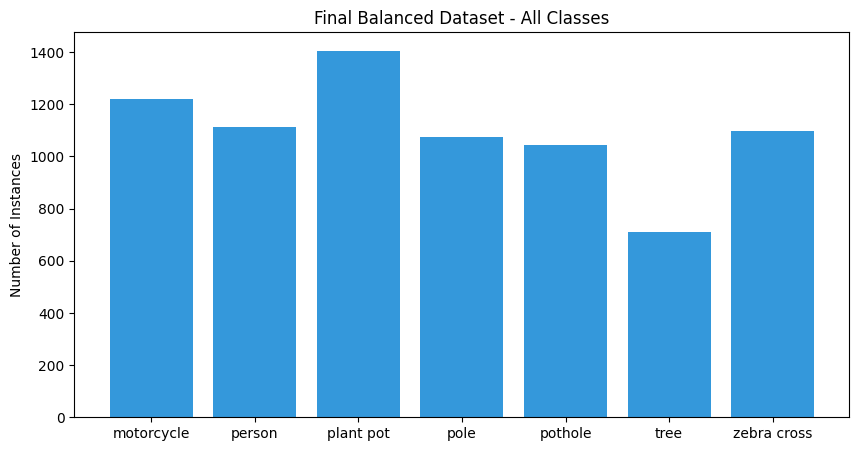

In [42]:
import os
import glob
import matplotlib.pyplot as plt

# Check the final super folder
label_dir = 'drishti_final_dataset/labels'
class_names = ['motorcycle', 'person', 'plant pot', 'pole', 'pothole', 'tree', 'zebra cross']
stats = {name: 0 for name in class_names}

files = glob.glob(os.path.join(label_dir, '*.txt'))
print(f"Total files in final dataset: {len(files)}")

for label_file in files:
    with open(label_file, 'r') as f:
        for line in f:
            if line.strip():
                try:
                    class_id = int(float(line.split()[0]))
                except (ValueError, IndexError):
                    continue
                if class_id < len(class_names):
                    stats[class_names[class_id]] += 1

print("\nUPDATED FINAL DISTRIBUTION")
print("-" * 40)
for name, count in stats.items():
    print(f"{name:15}: {count} instances")

plt.figure(figsize=(10, 5))
plt.bar(stats.keys(), stats.values(), color='#3498db')
plt.title("Final Balanced Dataset - All Classes")
plt.ylabel("Number of Instances")
plt.show()

In [43]:
import os
import cv2
import random
import albumentations as A
from glob import glob
from tqdm import tqdm

# 1. Setup
BASE_DIR = 'drishti_final_dataset'
LBL_DIR = os.path.join(BASE_DIR, 'labels')
IMG_DIR = os.path.join(BASE_DIR, 'images')

# 2. SELECT YOUR TARGET HERE (Run one by one)
# 2 = plant pot, 3 = pole, 5 = tree, 6 = zebra cross
TARGET_CLASS_ID = 5
TARGET_BOOST = 300   # Add enough to reach ~1000
class_name = ['motorcycle', 'person', 'plant pot', 'pole', 'pothole', 'tree', 'zebra cross'][TARGET_CLASS_ID]

# 3. Augmentation Logic
aug = A.Compose([
    A.RandomBrightnessContrast(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=20, p=0.6),
    A.HorizontalFlip(p=0.5),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 4. Filter and Execute
all_labels = glob(os.path.join(LBL_DIR, '*.txt'))
pool = [lbl for lbl in all_labels if any(line.strip() and line.split()[0] == str(TARGET_CLASS_ID) for line in open(lbl))]

if pool:
    print(f"Boosting {class_name.upper()}: Creating {TARGET_BOOST} new samples...")
    for i in tqdm(range(TARGET_BOOST)):
        lbl_path = random.choice(pool)
        img_path = os.path.join(IMG_DIR, os.path.basename(lbl_path).replace('.txt', '.jpg'))
        image = cv2.imread(img_path)
        if image is None: continue
        
        labels, bboxes = [], []
        for line in open(lbl_path):
            parts = list(map(float, line.split()))
            labels.append(int(parts[0])); bboxes.append(parts[1:])
        
        try:
            t = aug(image=image, bboxes=bboxes, class_labels=labels)
            new_fn = f"boost_{class_name}_{i}"
            cv2.imwrite(os.path.join(IMG_DIR, f"{new_fn}.jpg"), t['image'])
            with open(os.path.join(LBL_DIR, f"{new_fn}.txt"), 'w') as f:
                for l, b in zip(t['class_labels'], t['bboxes']):
                    f.write(f"{l} {' '.join(map(str, b))}\n")
        except: continue

Boosting TREE: Creating 300 new samples...


100%|██████████| 300/300 [00:02<00:00, 133.92it/s]


Total files in final dataset: 6453

UPDATED FINAL DISTRIBUTION
----------------------------------------
motorcycle     : 1249 instances
person         : 1123 instances
plant pot      : 1410 instances
pole           : 1121 instances
pothole        : 1050 instances
tree           : 1055 instances
zebra cross    : 1101 instances


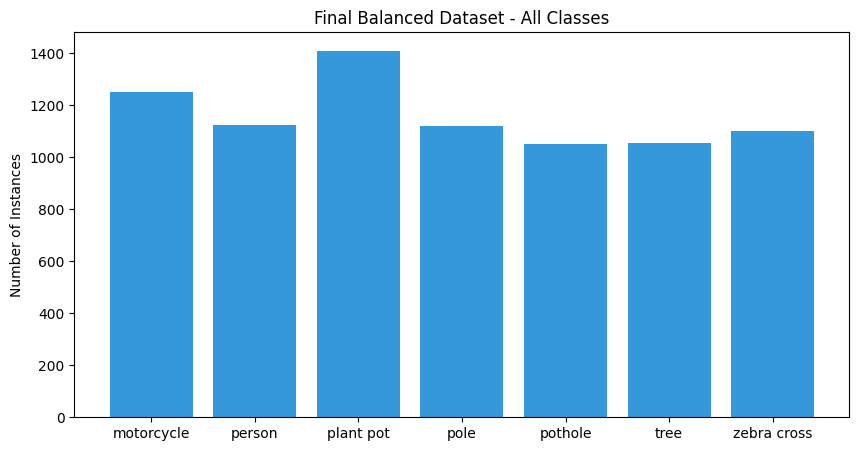

Final distribution chart saved as drishti_final_distribution.png


<Figure size 640x480 with 0 Axes>

In [45]:
import os
import glob
import matplotlib.pyplot as plt

# Check the final super folder
label_dir = 'drishti_final_dataset/labels'
class_names = ['motorcycle', 'person', 'plant pot', 'pole', 'pothole', 'tree', 'zebra cross']
stats = {name: 0 for name in class_names}

files = glob.glob(os.path.join(label_dir, '*.txt'))
print(f"Total files in final dataset: {len(files)}")

for label_file in files:
    with open(label_file, 'r') as f:
        for line in f:
            if line.strip():
                try:
                    class_id = int(float(line.split()[0]))
                except (ValueError, IndexError):
                    continue
                if class_id < len(class_names):
                    stats[class_names[class_id]] += 1

print("\nUPDATED FINAL DISTRIBUTION")
print("-" * 40)
for name, count in stats.items():
    print(f"{name:15}: {count} instances")

plt.figure(figsize=(10, 5))
plt.bar(stats.keys(), stats.values(), color='#3498db')
plt.title("Final Balanced Dataset - All Classes")
plt.ylabel("Number of Instances")
plt.show()


# After your plotting code:
plt.savefig('drishti_final_distribution.png', dpi=300, bbox_inches='tight')
print("Final distribution chart saved as drishti_final_distribution.png")

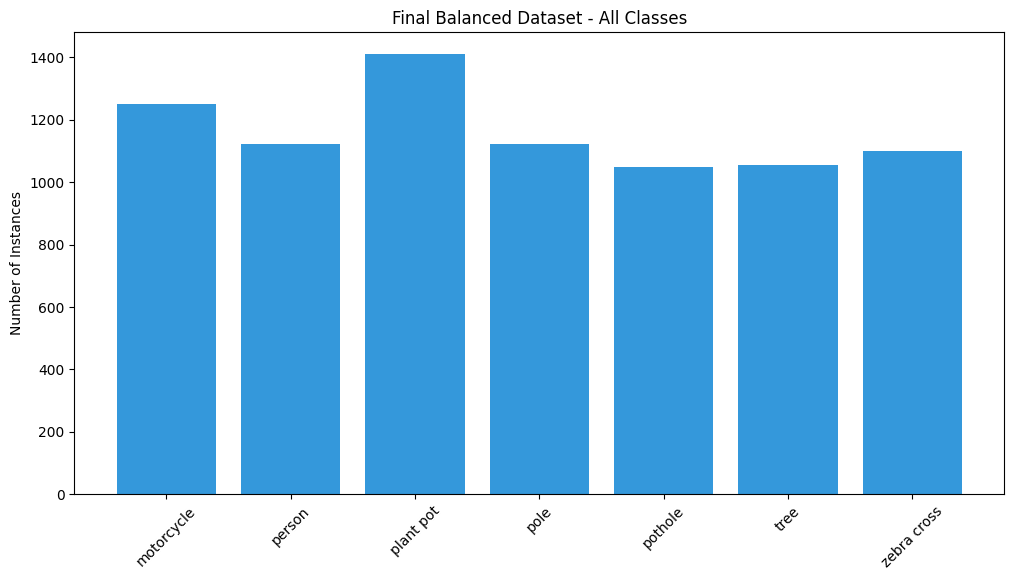

Chart successfully saved to: ml_pipeline_Obstacle_det/drishti_final_distribution.png


In [47]:
import os
import glob
import matplotlib.pyplot as plt

# Audit the final super folder
label_dir = 'drishti_final_dataset/labels'
class_names = ['motorcycle', 'person', 'plant pot', 'pole', 'pothole', 'tree', 'zebra cross']
stats = {name: 0 for name in class_names}

for label_file in glob.glob(os.path.join(label_dir, '*.txt')):
    with open(label_file, 'r') as f:
        for line in f:
            if line.strip():
                try:
                    class_id = int(float(line.split()[0]))
                except (ValueError, IndexError):
                    continue
                if class_id < len(class_names):
                    stats[class_names[class_id]] += 1

# Create the plot
plt.figure(figsize=(12, 6))
plt.bar(stats.keys(), stats.values(), color='#3498db')
plt.title("Final Balanced Dataset - All Classes")
plt.ylabel("Number of Instances")
plt.xticks(rotation=45)

# CRITICAL: Save BEFORE calling plt.show()
save_path = 'ml_pipeline_Obstacle_det/drishti_final_distribution.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Chart successfully saved to: {save_path}")

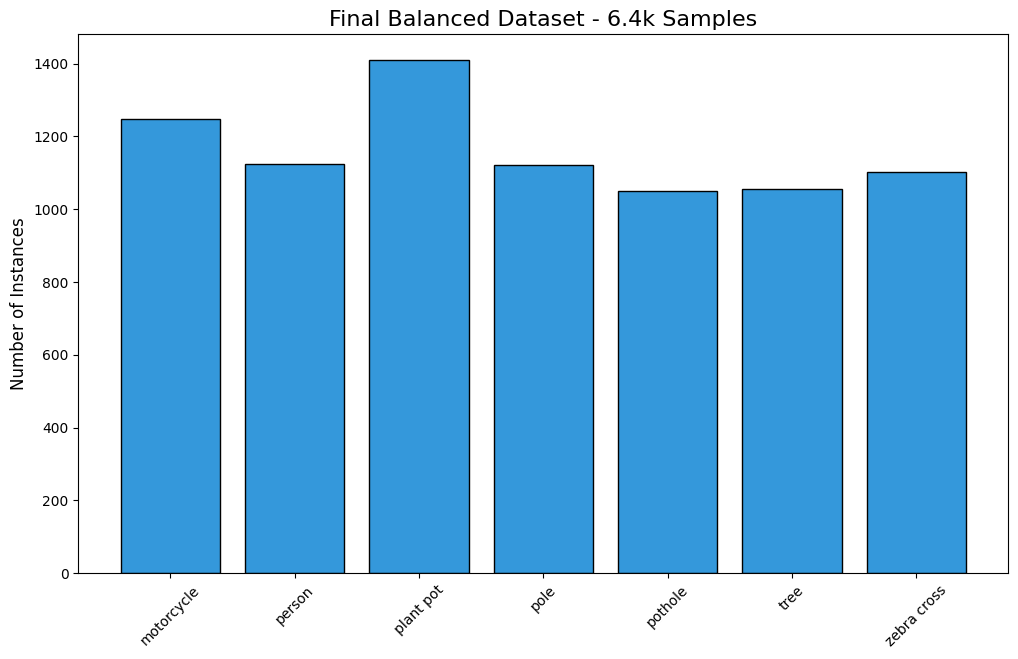

Chart successfully saved to: ml_pipeline_Obstacle_det/drishti_final_distribution.png


In [53]:
import os
import glob
import matplotlib.pyplot as plt

# 1. Clear everything first
plt.clf()
plt.close('all')

# 2. Recalculate from your final super folder
label_dir = 'drishti_final_dataset/labels'
class_names = ['motorcycle', 'person', 'plant pot', 'pole', 'pothole', 'tree', 'zebra cross']
stats = {name: 0 for name in class_names}

for label_file in glob.glob(os.path.join(label_dir, '*.txt')):
    with open(label_file, 'r') as f:
        for line in f:
            if line.strip():
                try:
                    class_id = int(float(line.split()[0]))
                except (ValueError, IndexError):
                    continue
                if class_id < len(class_names):
                    stats[class_names[class_id]] += 1

# 3. Build the plot with a white background (fixes GitHub dark mode issues)
fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')
ax.bar(stats.keys(), stats.values(), color='#3498db', edgecolor='black')
ax.set_title("Final Balanced Dataset - 6.4k Samples", fontsize=16)
ax.set_ylabel("Number of Instances", fontsize=12)
plt.xticks(rotation=45)

# 4. Save with high resolution BEFORE showing
save_path = 'ml_pipeline_Obstacle_det/drishti_final_distribution.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Chart successfully saved to: {save_path}")